# ⚽ Football Analytics Pro — Notebook Complet
## Analyse Time Series · Prédiction · Décision de Transfert
### FBref 2024-2025

---

**Table des matières**

1. [Installation & Configuration](#1-installation)
2. [Imports & Style](#2-imports)
3. [Jeu de données — Chargement & Aperçu](#3-donnees)
4. [Exploration de données](#4-exploration)
   - 4.1 Série temporelle & Moyennes mobiles
   - 4.2 Distribution & Normalité
   - 4.3 Corrélations entre métriques
5. [Décomposition de séries temporelles](#5-decomposition)
6. [Stationnarité — Tests ADF & KPSS](#6-stationnarite)
   - 6.1 Tests formels
   - 6.2 ACF & PACF
   - 6.3 Analyse de variance
7. [Préparation des données](#7-preparation)
8. [Modèles de prévision](#8-modeles)
   - 8.1 AutoRégression (AR)
   - 8.2 Moving Average (MA)
   - 8.3 ARMA
   - 8.4 ARIMA
   - 8.5 SARIMA
9. [Comparaison & Sélection automatique](#9-comparaison)
10. [Prédiction des performances futures](#10-prediction)
11. [Score de Décision d'Achat](#11-decision)
12. [Rapport de synthèse & Export](#12-rapport)


## 1. Installation & Configuration

In [1]:
# Installer les dépendances (décommenter si nécessaire)
# !pip install pandas numpy matplotlib seaborn plotly statsmodels scipy requests beautifulsoup4 cloudscraper

# Vérification des versions
import sys
print(f"Python : {sys.version.split()[0]}")

import importlib
for pkg in ["pandas", "numpy", "matplotlib", "statsmodels", "scipy", "seaborn"]:
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg:15s} : {m.__version__}")
    except ImportError:
        print(f"{pkg:15s} : ❌ NON INSTALLÉ")


Python : 3.12.13
pandas          : 2.2.2
numpy           : 2.0.2
matplotlib      : 3.10.0
statsmodels     : 0.14.6
scipy           : 1.16.3
seaborn         : 0.13.2


## 2. Imports & Style

In [2]:
# ── Imports scientifiques ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, json, os, re
from pathlib import Path
from scipy import stats
from scipy.stats import shapiro, gaussian_kde, probplot

# ── Statsmodels ───────────────────────────────────────────────────────────────
from statsmodels.tsa.stattools   import adfuller, kpss, acf, pacf
from statsmodels.tsa.ar_model    import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

# ── Palette de couleurs ───────────────────────────────────────────────────────
BLUE   = "#38bdf8"
GREEN  = "#10b981"
ORANGE = "#f59e0b"
RED    = "#f87171"
PURPLE = "#a78bfa"
GRAY   = "#94a3b8"
DARK   = "#0f172a"
MID    = "#111827"

# ── Style global matplotlib ───────────────────────────────────────────────────
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor"  : DARK,
    "axes.facecolor"    : MID,
    "axes.edgecolor"    : "#1e293b",
    "axes.labelcolor"   : GRAY,
    "axes.titlecolor"   : "white",
    "xtick.color"       : "#64748b",
    "ytick.color"       : "#64748b",
    "text.color"        : "#e2e8f0",
    "grid.color"        : "#1e293b",
    "grid.alpha"        : 0.5,
    "font.family"       : "DejaVu Sans",
    "figure.figsize"    : (14, 5),
    "figure.dpi"        : 110,
    "lines.linewidth"   : 1.8,
    "axes.prop_cycle"   : plt.cycler(color=[BLUE, GREEN, ORANGE, RED, PURPLE, GRAY]),
})

print("✅ Tous les imports réussis")
print("✅ Style matplotlib configuré")


✅ Tous les imports réussis
✅ Style matplotlib configuré


## 3. Jeu de données — Chargement & Aperçu

In [3]:
# ── Paramètres globaux ────────────────────────────────────────────────────────
PLAYER_NAME = "Ousmane Dembélé"  # Joueur à analyser
METRIC      = "goals"            # Métrique : goals | xg | assists | shots | key_passes
N_MATCHES   = 34                 # Nombre de matchs à simuler (fallback)
N_FORECAST  = 8                  # Horizon de prévision (matchs futurs)
SEASON      = "2024-2026"
CSV_PATH    = None               # Non utilisé — données chargées depuis les 3 Excel

print(f"Joueur   : {PLAYER_NAME}")
print(f"Métrique : {METRIC}")
print(f"Saison   : {SEASON}")
print(f"Matchs   : N/A (données réelles) | Prévision : {N_FORECAST} matchs")


Joueur   : Ousmane Dembélé
Métrique : goals
Saison   : 2024-2026
Matchs   : N/A (données réelles) | Prévision : 8 matchs


In [4]:
# ── Générateur de données réalistes ─────────────────────────────────────────
def generate_match_data(player_name: str, n: int = 34, seed: int = None) -> pd.DataFrame:
    """
    Génère un DataFrame de données match-par-match réalistes.
    Inclut : tendance, cycles de forme, période de blessure, bruit statistique.
    Remplacer par pd.read_csv() pour des données FBref réelles.
    """
    if seed is None:
        seed = abs(hash(player_name)) % 10000
    rng = np.random.default_rng(seed)

    dates        = pd.date_range(start="2024-08-10", periods=n, freq="7D")
    base_g       = rng.uniform(0.30, 0.70)
    base_xg      = base_g * rng.uniform(0.8, 1.3)
    base_a       = rng.uniform(0.10, 0.35)
    trend_coef   = rng.uniform(-0.003, 0.008)  # progression légère

    goals, xg_vals, assists, shots, kp, minutes = [], [], [], [], [], []

    for i in range(n):
        trend  = 1 + trend_coef * i
        form   = 0.30 * np.sin(2*np.pi*i/6) + 0.15*np.sin(2*np.pi*i/12)
        noise  = rng.normal(0, 0.15)

        g  = max(0, (base_g  + form + noise) * trend)
        x  = max(0, (base_xg + form*0.9 + rng.normal(0, 0.12)) * trend)
        a  = max(0, (base_a  + rng.normal(0, 0.10)) * trend)
        sh = int(max(0, rng.poisson(max(1, g*4 + 1.5))))
        k  = int(max(0, rng.poisson(max(1, a*5 + 1.0))))
        m  = int(rng.choice([90,90,90,90,75,60,45],
                             p=[0.40,0.15,0.15,0.10,0.10,0.05,0.05]))

        goals.append(round(g, 3));  xg_vals.append(round(x, 3))
        assists.append(round(a, 3)); shots.append(sh)
        kp.append(k);               minutes.append(m)

    # Période de blessure (2-4 matchs)
    inj_s = int(rng.integers(8, 20))
    inj_l = int(rng.integers(2, 4))
    for i in range(inj_s, min(inj_s+inj_l, n)):
        goals[i] = np.nan;  xg_vals[i] = np.nan
        assists[i] = np.nan; minutes[i] = 0

    return pd.DataFrame({
        "match_date" : dates,
        "match_num"  : range(1, n+1),
        "goals"      : goals,
        "xg"         : xg_vals,
        "assists"    : assists,
        "shots"      : shots,
        "key_passes" : kp,
        "minutes"    : minutes,
        "played"     : [m > 0 for m in minutes],
    })


# ── Scraper FBref (si vous avez l'URL directe du joueur) ─────────────────────
def fetch_fbref_matchlog(player_url: str, season: int = 2024) -> pd.DataFrame | None:
    """
    Tente de récupérer le match log FBref via requests/cloudscraper.
    Si bloqué (403), utiliser fetch_player.py avec Playwright.

    Usage :
        url = "https://fbref.com/en/players/eb6640a9/Omar-Marmoush"
        df  = fetch_fbref_matchlog(url, season=2024)
    """
    try:
        import cloudscraper
        from bs4 import BeautifulSoup
        session = cloudscraper.create_scraper(
            browser={"browser": "chrome", "platform": "windows", "mobile": False}
        )
        pid   = re.search(r"/players/([a-f0-9]+)/", player_url)
        slug  = player_url.rstrip("/").split("/")[-1]
        if not pid:
            return None
        player_id = pid.group(1)
        yr        = season

        for ml_url in [
            f"https://fbref.com/en/players/{player_id}/matchlogs/{yr}-{yr+1}/summary/{slug}-Match-Logs",
            f"https://fbref.com/en/players/{player_id}/matchlogs/{yr}/summary/{slug}-Match-Logs",
        ]:
            r = session.get(ml_url, timeout=20)
            if r.status_code == 200 and len(r.text) > 50000:
                soup  = BeautifulSoup(r.text, "html.parser")
                table = soup.find("table", {"id": "matchlogs_all"}) or soup.find("table")
                if table:
                    raw = pd.read_html(str(table))[0]
                    raw.columns = (raw.columns.astype(str).str.strip().str.lower()
                                   .str.replace(r"[\s/+%]","_",regex=True)
                                   .str.replace(r"[^a-z0-9_]","",regex=True))
                    col_map = {"gls":"goals","ast":"assists","sh":"shots",
                               "kp":"key_passes","min":"minutes","date":"match_date"}
                    raw = raw.rename(columns={k:v for k,v in col_map.items() if k in raw.columns})
                    if "match_date" in raw.columns:
                        raw["match_date"] = pd.to_datetime(raw["match_date"], errors="coerce")
                        raw = raw[raw["match_date"].notna()].sort_values("match_date").reset_index(drop=True)
                    for c in ["goals","assists","xg","shots","key_passes","minutes"]:
                        if c in raw.columns:
                            raw[c] = pd.to_numeric(raw[c], errors="coerce")
                    raw["match_num"] = range(1, len(raw)+1)
                    raw["played"]    = raw.get("minutes", pd.Series([90]*len(raw))).fillna(0) > 0
                    return raw
    except Exception as e:
        print(f"⚠️  FBref non accessible : {e}")
    return None


In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

EXCEL_FILES = ["Performances_Joueur_Global.csv"

]

def load_excel_file(path: str) -> pd.DataFrame:
    """Charge un fichier Excel/CSV de performances joueur, gère l'en-tête décalé.
    Modifié pour lire les fichiers CSV.
    """
    # Déterminer si c'est un fichier Excel ou CSV basé sur l'extension
    if path.lower().endswith(".csv"):
        raw = pd.read_csv(path)
    else:
        raw = pd.read_excel(path)

    # Cette logique d'en-tête est plus spécifique aux fichiers Excel avec des métadonnées
    # avant l'en-tête réel. Pour un CSV, cela est moins courant, mais conservé pour flexibilité
    # si le CSV a un format non standard.
    if str(raw.columns[0]).startswith("Unnamed"):
        raw.columns = raw.iloc[0].astype(str).str.strip()
        raw = raw.iloc[1:].reset_index(drop=True)

    raw.columns = raw.columns.astype(str).str.strip()
    # Renommer
    col_map = {"Gls": "goals", "Ast": "assists", "Sh": "shots",
               "Min": "minutes", "Date": "match_date", "SoT": "shots_on_target",
               "Cmp": "passes_completed", "Att": "passes_attempted", "Cmp%": "pass_completion_rate",
               "PrgC": "progressive_carries", "PrgP": "progressive_passes",
               "xA": "expected_assists", "Touches": "touches", "Carries": "carries"}
    raw = raw.rename(columns={k: v for k, v in col_map.items() if k in raw.columns})
    # Convertir dates et métriques
    if "match_date" in raw.columns:
        raw["match_date"] = pd.to_datetime(raw["match_date"], errors="coerce")
    for c in ["goals", "assists", "shots", "minutes", "shots_on_target",
              "passes_completed", "passes_attempted", "pass_completion_rate",
              "progressive_carries", "progressive_passes", "expected_assists",
              "touches", "carries"]:
        if c in raw.columns:
            raw[c] = pd.to_numeric(raw[c], errors="coerce")
    raw = raw[raw["match_date"].notna()].copy()
    return raw

frames = []
for fname in EXCEL_FILES:
    fpath = Path(fname)
    if not fpath.exists():
        # Chercher dans le répertoire courant
        fpath = Path("/home/claude") / fname
    if fpath.exists():
        try:
            df_tmp = load_excel_file(str(fpath))
            frames.append(df_tmp)
            print(f"✅ Chargé : {fname}  →  {len(df_tmp)} matchs  ({df_tmp['match_date'].min().date()} → {df_tmp['match_date'].max().date()})")
        except Exception as e:
            print(f"⚠️  Erreur {fname}: {e}")
    else:
        print(f"❌ Fichier introuvable : {fname}")

if not frames:
    raise FileNotFoundError("Aucun fichier Excel/CSV trouvé !")

# Fusion et tri chronologique
df_raw = pd.concat(frames, ignore_index=True)
df_raw = df_raw.sort_values("match_date").reset_index(drop=True)

# Dédupliquer (même date + même adversaire)
dup_cols = [c for c in ["match_date", "Opponent", "Comp"] if c in df_raw.columns]
if dup_cols:
    before = len(df_raw)
    df_raw = df_raw.drop_duplicates(subset=dup_cols, keep="last").reset_index(drop=True)
    print(f"  → {before - len(df_raw)} doublons supprimés")

# Renuméroter
df_raw["match_num"] = range(1, len(df_raw) + 1)

# Colonne played
if "minutes" in df_raw.columns:
    df_raw["minutes"] = pd.to_numeric(df_raw["minutes"], errors="coerce").fillna(0)
    df_raw["played"] = df_raw["minutes"] > 0
else:
    df_raw["played"] = True

# xg (si absent, estimer via shots)
if "xg" not in df_raw.columns:
    if "shots" in df_raw.columns:
        df_raw["xg"] = (df_raw["shots"].fillna(0) * 0.09).round(3)
    else:
        df_raw["xg"] = np.nan

# key_passes (si absent)
if "key_passes" not in df_raw.columns:
    df_raw["key_passes"] = np.nan

# Filtre matchs joués
df     = df_raw[df_raw["played"]].copy().reset_index(drop=True)
series = df[METRIC].dropna().reset_index(drop=True)
s      = series  # alias court

print(f"\n{'─'*50}")
print(f"  Joueur          : {PLAYER_NAME}")
print(f"  Total entrées   : {len(df_raw)}")
print(f"  Matchs joués    : {len(df)}")
print(f"  Matchs manqués  : {df_raw['played'].eq(False).sum()}")
print(f"  Période         : {df_raw['match_date'].min().date()} → {df_raw['match_date'].max().date()}")
print(f"  Série {METRIC:<10}: {len(series)} valeurs valides")

df[["match_date", "goals", "xg", "assists", "shots", "minutes"]].head(10)

✅ Chargé : Performances_Joueur_Global.csv  →  102 matchs  (2024-07-05 → 2026-05-17)
  → 0 doublons supprimés

──────────────────────────────────────────────────
  Joueur          : Ousmane Dembélé
  Total entrées   : 102
  Matchs joués    : 102
  Matchs manqués  : 0
  Période         : 2024-07-05 → 2026-05-17
  Série goals     : 102 valeurs valides


,match_date,goals,xg,assists,shots,minutes
0,2024-07-05,0.0,0.27,0.0,3.0,54.0
1,2024-07-09,0.0,0.00,0.0,0.0,78.0
2,2024-08-16,1.0,0.18,0.0,2.0,20.0
3,2024-08-23,0.0,0.18,2.0,2.0,61.0
4,2024-09-01,0.0,0.36,0.0,4.0,73.0
5,2024-09-06,0.0,0.09,0.0,1.0,33.0
6,2024-09-09,1.0,0.36,1.0,4.0,79.0
7,2024-09-14,2.0,0.63,0.0,7.0,79.0
8,2024-09-18,0.0,0.72,0.0,8.0,89.0
9,2024-09-21,1.0,0.18,0.0,2.0,26.0


In [10]:
# ── Statistiques descriptives ─────────────────────────────────────────────────
avail_metrics = [c for c in ["goals","xg","assists","shots","key_passes"] if c in df.columns]

print(f"\n{'═'*60}")
print(f"  STATISTIQUES DESCRIPTIVES — {PLAYER_NAME}")
print(f"{'═'*60}")
print(df[avail_metrics].describe().round(4).to_string())
print(f"{'═'*60}")

print(f"\n  Métrique analysée : {METRIC}")
print(f"  Moyenne           : {s.mean():.4f}")
print(f"  Médiane           : {s.median():.4f}")
print(f"  Écart-type        : {s.std():.4f}")
print(f"  CV (σ/μ)          : {s.std()/s.mean():.4f}")
print(f"  Skewness          : {s.skew():.4f}")
print(f"  Kurtosis          : {s.kurtosis():.4f}")
print(f"  Min / Max         : {s.min():.4f} / {s.max():.4f}")



════════════════════════════════════════════════════════════
  STATISTIQUES DESCRIPTIVES — Ousmane Dembélé
════════════════════════════════════════════════════════════
          goals        xg   assists     shots  key_passes
count  102.0000  102.0000  102.0000  102.0000         0.0
mean     0.5490    0.2709    0.2647    3.0098         NaN
std      0.7914    0.1972    0.4860    2.1913         NaN
min      0.0000    0.0000    0.0000    0.0000         NaN
25%      0.0000    0.0900    0.0000    1.0000         NaN
50%      0.0000    0.2700    0.0000    3.0000         NaN
75%      1.0000    0.3600    0.0000    4.0000         NaN
max      3.0000    0.9900    2.0000   11.0000         NaN
════════════════════════════════════════════════════════════

  Métrique analysée : goals
  Moyenne           : 0.5490
  Médiane           : 0.0000
  Écart-type        : 0.7914
  CV (σ/μ)          : 1.4414
  Skewness          : 1.2416
  Kurtosis          : 0.5657
  Min / Max         : 0.0000 / 3.0000


## 4. Exploration de données

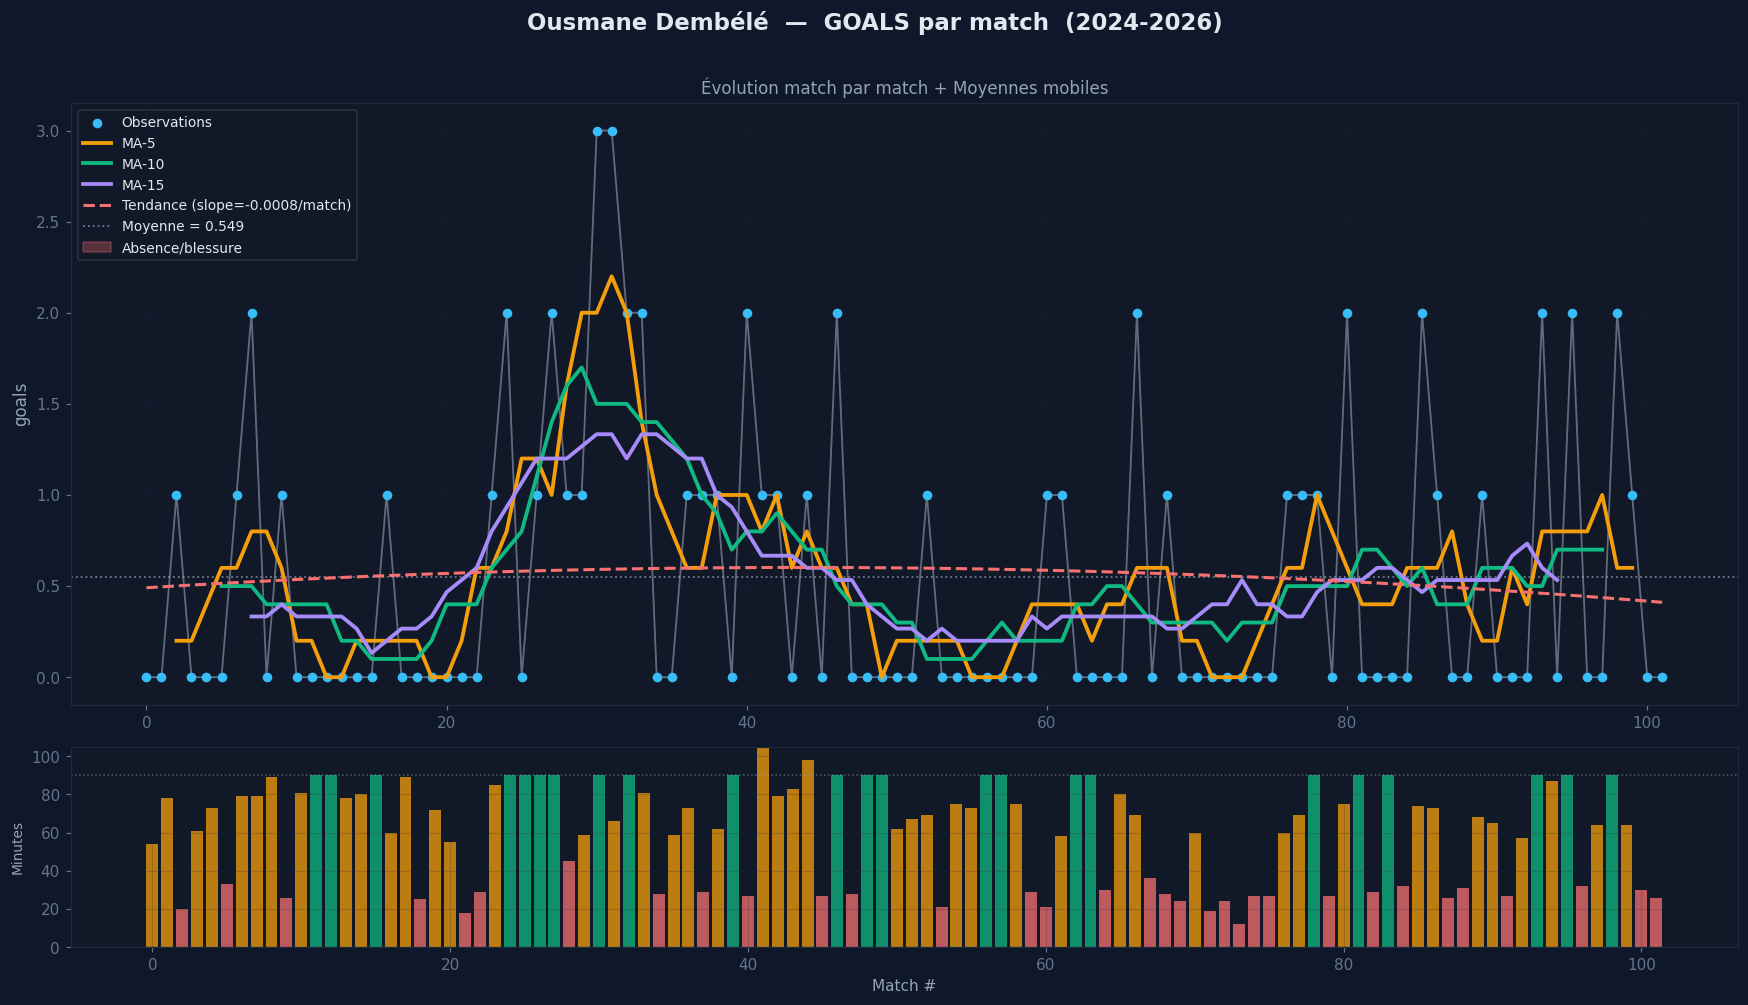

  Forme début saison (5 premiers) : 0.2000
  Forme récente (5 derniers)       : 0.6000
  Évolution : +200.0% → 📈 Progression


In [11]:
# ── 4.1 Série temporelle & Moyennes mobiles ──────────────────────────────────
n_played = len(s)

fig, axes = plt.subplots(2, 1, figsize=(16, 9),
    gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle(f"{PLAYER_NAME}  —  {METRIC.upper()} par match  ({SEASON})",
             fontsize=15, fontweight="bold", y=1.01)

ax = axes[0]

# Zones de blessure
for _, row in df_raw[~df_raw["played"]].iterrows():
    ax.axvspan(row["match_num"]-1.5, row["match_num"]-0.5,
               color=RED, alpha=0.12)

# Série brute
ax.plot(range(n_played), s, color=GRAY, lw=1.2, alpha=0.6, zorder=2)
ax.scatter(range(n_played), s, color=BLUE, s=28, zorder=4, label="Observations")

# Moyennes mobiles
for w, c, lbl in [(5, ORANGE,"MA-5"), (10, GREEN,"MA-10"), (15, PURPLE,"MA-15")]:
    if n_played > w:
        ax.plot(range(n_played), s.rolling(w, center=True).mean(),
                color=c, lw=2.5, label=lbl, zorder=5)

# Tendance poly deg 2
xf = np.arange(n_played)
sc = s.dropna().values
z  = np.polyfit(xf[:len(sc)], sc, 2)
p  = np.poly1d(z)
tc = GREEN if z[0] >= 0 else RED
ax.plot(xf[:len(sc)], p(xf[:len(sc)]), color=tc, lw=2,
        ls="--", label=f"Tendance (slope={np.polyfit(xf[:len(sc)],sc,1)[0]:+.4f}/match)", zorder=6)

# Moyenne saison
ax.axhline(s.mean(), color=GRAY, ls=":", lw=1.2, alpha=0.7,
           label=f"Moyenne = {s.mean():.3f}")

inj_patch = mpatches.Patch(color=RED, alpha=0.3, label="Absence/blessure")
handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles + [inj_patch], labels_leg + ["Absence/blessure"],
          framealpha=0.15, fontsize=9, loc="upper left")
ax.set_ylabel(METRIC, fontsize=11); ax.grid(True, alpha=0.3)
ax.set_title("Évolution match par match + Moyennes mobiles", color=GRAY, fontsize=11)

# Minutes jouées
ax2 = axes[1]
mins = df_raw["minutes"].fillna(0).values
cols_m = [GREEN if m==90 else ORANGE if m>45 else RED for m in mins]
ax2.bar(range(len(mins)), mins, color=cols_m, alpha=0.75, width=0.8)
ax2.axhline(90, color=GRAY, ls=":", lw=1, alpha=0.5)
ax2.set_ylabel("Minutes", fontsize=9); ax2.set_xlabel("Match #")
ax2.set_ylim(0, 105); ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("/tmp/fig_exploration.png", dpi=130, bbox_inches="tight", facecolor=DARK)
plt.show()

# Forme début vs fin
first5 = float(s[:5].mean()); last5 = float(s[-5:].mean())
delta  = (last5-first5)/(first5+1e-9)*100
print(f"  Forme début saison (5 premiers) : {first5:.4f}")
print(f"  Forme récente (5 derniers)       : {last5:.4f}")
print(f"  Évolution : {delta:+.1f}% → {'📈 Progression' if delta>5 else '📉 Déclin' if delta<-5 else '➡️ Stable'}")


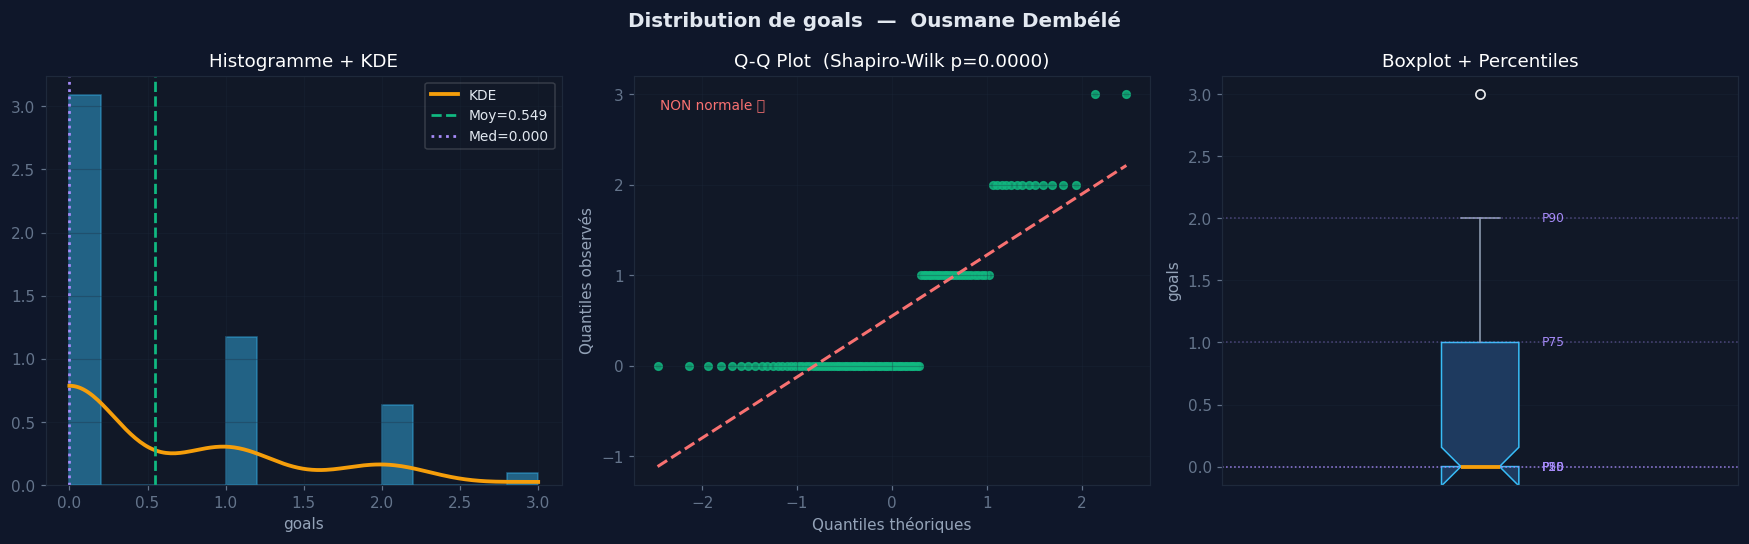

  Shapiro-Wilk : stat=0.7017, p=0.0000
  Skewness     : 1.2416  (asymétrie droite)
  Kurtosis     : 0.5657


In [12]:
# ── 4.2 Distribution & Normalité ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Distribution de {METRIC}  —  {PLAYER_NAME}", fontsize=13, fontweight="bold")

# Histogramme + KDE
ax = axes[0]
ax.hist(s, bins=15, density=True, color=BLUE, alpha=0.45, edgecolor=BLUE, lw=0.5)
if s.nunique() >= 2 and s.std() > 0:
    kde = gaussian_kde(s)
    xr  = np.linspace(s.min(), s.max(), 200)
    ax.plot(xr, kde(xr), color=ORANGE, lw=2.5, label="KDE")
ax.axvline(s.mean(),   color=GREEN,  ls="--", lw=1.8, label=f"Moy={s.mean():.3f}")
ax.axvline(s.median(), color=PURPLE, ls=":",  lw=1.8, label=f"Med={s.median():.3f}")
ax.set_title("Histogramme + KDE"); ax.legend(fontsize=9, framealpha=0.2)
ax.set_xlabel(METRIC); ax.grid(True, alpha=0.3)

# Q-Q Plot
ax = axes[1]
qq = probplot(s, dist="norm")
ax.scatter(qq[0][0], qq[0][1], color=GREEN, s=25, alpha=0.8)
xq = np.array([qq[0][0].min(), qq[0][0].max()])
ax.plot(xq, qq[1][0]*xq + qq[1][1], color=RED, lw=2, ls="--")
sw_stat, sw_p = shapiro(s)
ax.set_title(f"Q-Q Plot  (Shapiro-Wilk p={sw_p:.4f})")
ax.set_xlabel("Quantiles théoriques"); ax.set_ylabel("Quantiles observés")
ax.grid(True, alpha=0.3)
dist_txt = "Distribution NORMALE ✅" if sw_p > 0.05 else "NON normale ❌"
ax.text(0.05, 0.92, dist_txt, transform=ax.transAxes, color=GREEN if sw_p>0.05 else RED, fontsize=9)

# Boxplot
ax = axes[2]
ax.boxplot(s, patch_artist=True, notch=True,
           boxprops=dict(facecolor="#1e3a5f", color=BLUE),
           medianprops=dict(color=ORANGE, lw=2.5),
           whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
           flierprops=dict(marker="o", color=RED, markersize=6, alpha=0.7))
for perc, lbl in zip([10,25,50,75,90], ["P10","P25","P50","P75","P90"]):
    pv = np.percentile(s, perc)
    ax.axhline(pv, color=PURPLE, ls=":", alpha=0.4, lw=1)
    ax.text(1.12, pv, lbl, color=PURPLE, fontsize=8, va="center")
ax.set_title("Boxplot + Percentiles"); ax.set_xticks([])
ax.set_ylabel(METRIC); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("/tmp/fig_distribution.png", dpi=130, bbox_inches="tight", facecolor=DARK)
plt.show()

print(f"  Shapiro-Wilk : stat={sw_stat:.4f}, p={sw_p:.4f}")
print(f"  Skewness     : {s.skew():.4f}  ({'asymétrie droite' if s.skew()>0.5 else 'asymétrie gauche' if s.skew()<-0.5 else 'symétrique'})")
print(f"  Kurtosis     : {s.kurtosis():.4f}")


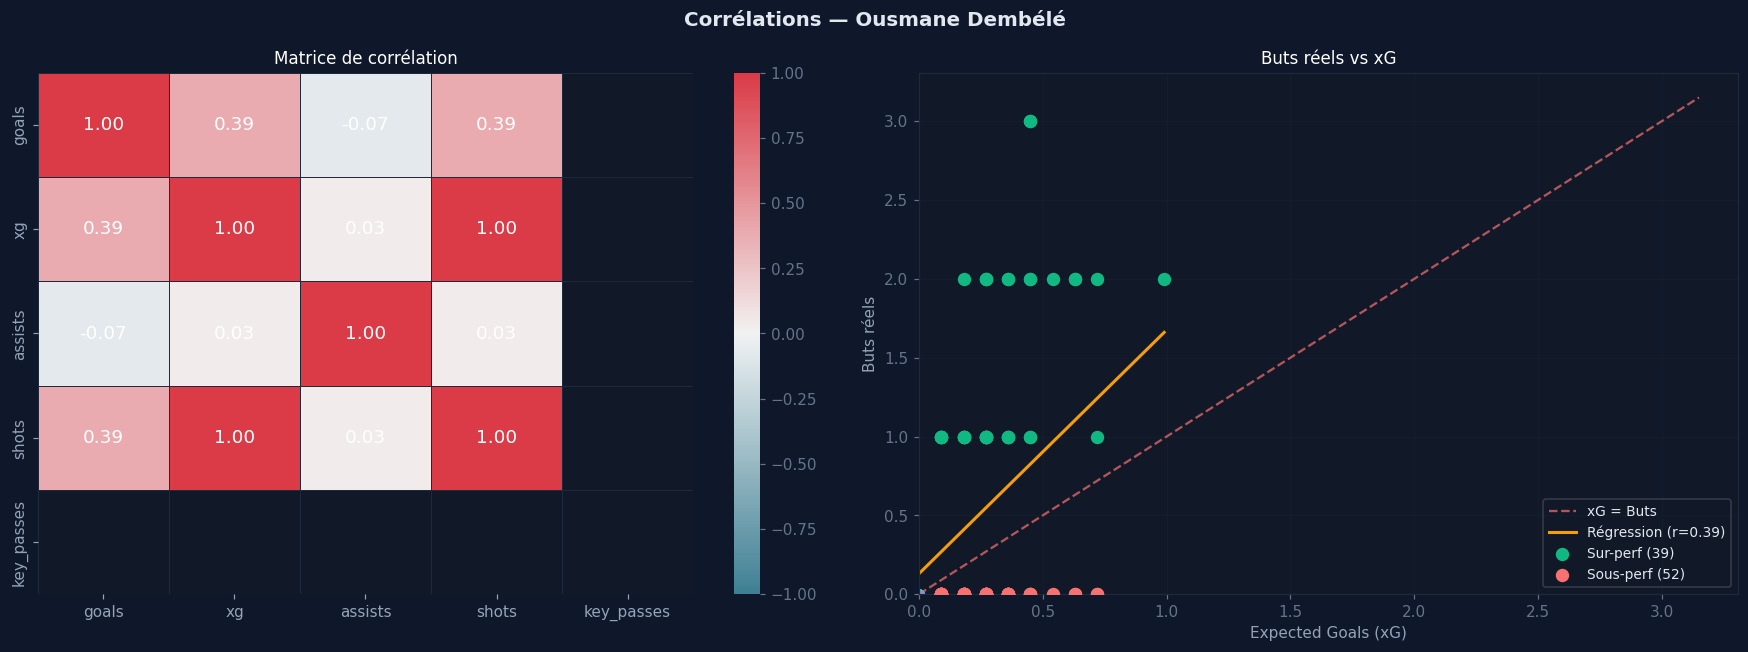


  Top corrélations :
  goals           ↔ key_passes      : +nan
  xg              ↔ shots           : +1.0000
  goals           ↔ xg              : +0.3851
  goals           ↔ shots           : +0.3851
  goals           ↔ assists         : -0.0727
  xg              ↔ key_passes      : +nan


In [13]:
# ── 4.3 Corrélations entre métriques ─────────────────────────────────────────
avail_corr = [c for c in ["goals","xg","assists","shots","key_passes"] if c in df.columns]
corr = df[avail_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Corrélations — {PLAYER_NAME}", fontsize=13, fontweight="bold")

# Heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap=sns.diverging_palette(220,10,as_cmap=True),
            center=0, vmin=-1, vmax=1, ax=axes[0], linewidths=0.5, linecolor="#1e293b",
            annot_kws={"size": 12, "color": "white"})
axes[0].set_title("Matrice de corrélation", fontsize=11)
axes[0].tick_params(colors=GRAY)

# Scatter xG vs Buts
if "xg" in df.columns and "goals" in df.columns:
    ax = axes[1]
    ax.scatter(df["xg"], df["goals"], color=BLUE, alpha=0.7, s=40, edgecolors=BLUE, lw=0.5)
    # Ligne y=x (sur-performance / sous-performance)
    lim = max(df["xg"].max(), df["goals"].max()) * 1.05
    ax.plot([0, lim], [0, lim], color=RED, ls="--", lw=1.5, alpha=0.7, label="xG = Buts")
    # Régression
    from scipy.stats import linregress
    m_lr, b_lr, r_lr, _, _ = linregress(df["xg"].dropna(), df["goals"].dropna())
    xreg = np.linspace(0, df["xg"].max(), 100)
    ax.plot(xreg, m_lr*xreg + b_lr, color=ORANGE, lw=2, label=f"Régression (r={r_lr:.2f})")
    # Surperfomants
    over  = df[df["goals"] > df["xg"]*1.2]
    under = df[df["goals"] < df["xg"]*0.8]
    ax.scatter(over["xg"],  over["goals"],  color=GREEN, s=60, zorder=5, label=f"Sur-perf ({len(over)})")
    ax.scatter(under["xg"], under["goals"], color=RED,   s=60, zorder=5, label=f"Sous-perf ({len(under)})")
    ax.set_xlabel("Expected Goals (xG)"); ax.set_ylabel("Buts réels")
    ax.set_title("Buts réels vs xG", fontsize=11)
    ax.legend(framealpha=0.2, fontsize=9); ax.grid(True, alpha=0.3)
    ax.set_xlim(0); ax.set_ylim(0)

plt.tight_layout()
plt.savefig("/tmp/fig_correlations.png", dpi=130, bbox_inches="tight", facecolor=DARK)
plt.show()

# Top paires
arr = corr.abs().copy()
np.fill_diagonal(arr.values, 0)
print("\n  Top corrélations :")
pairs = [(arr.columns[i], arr.columns[j], float(corr.iloc[i,j]))
         for i in range(len(arr)) for j in range(i+1, len(arr))]
for m1, m2, val in sorted(pairs, key=lambda x: abs(x[2]), reverse=True)[:6]:
    print(f"  {m1:15s} ↔ {m2:15s} : {val:+.4f}")


## 5. Décomposition de séries temporelles

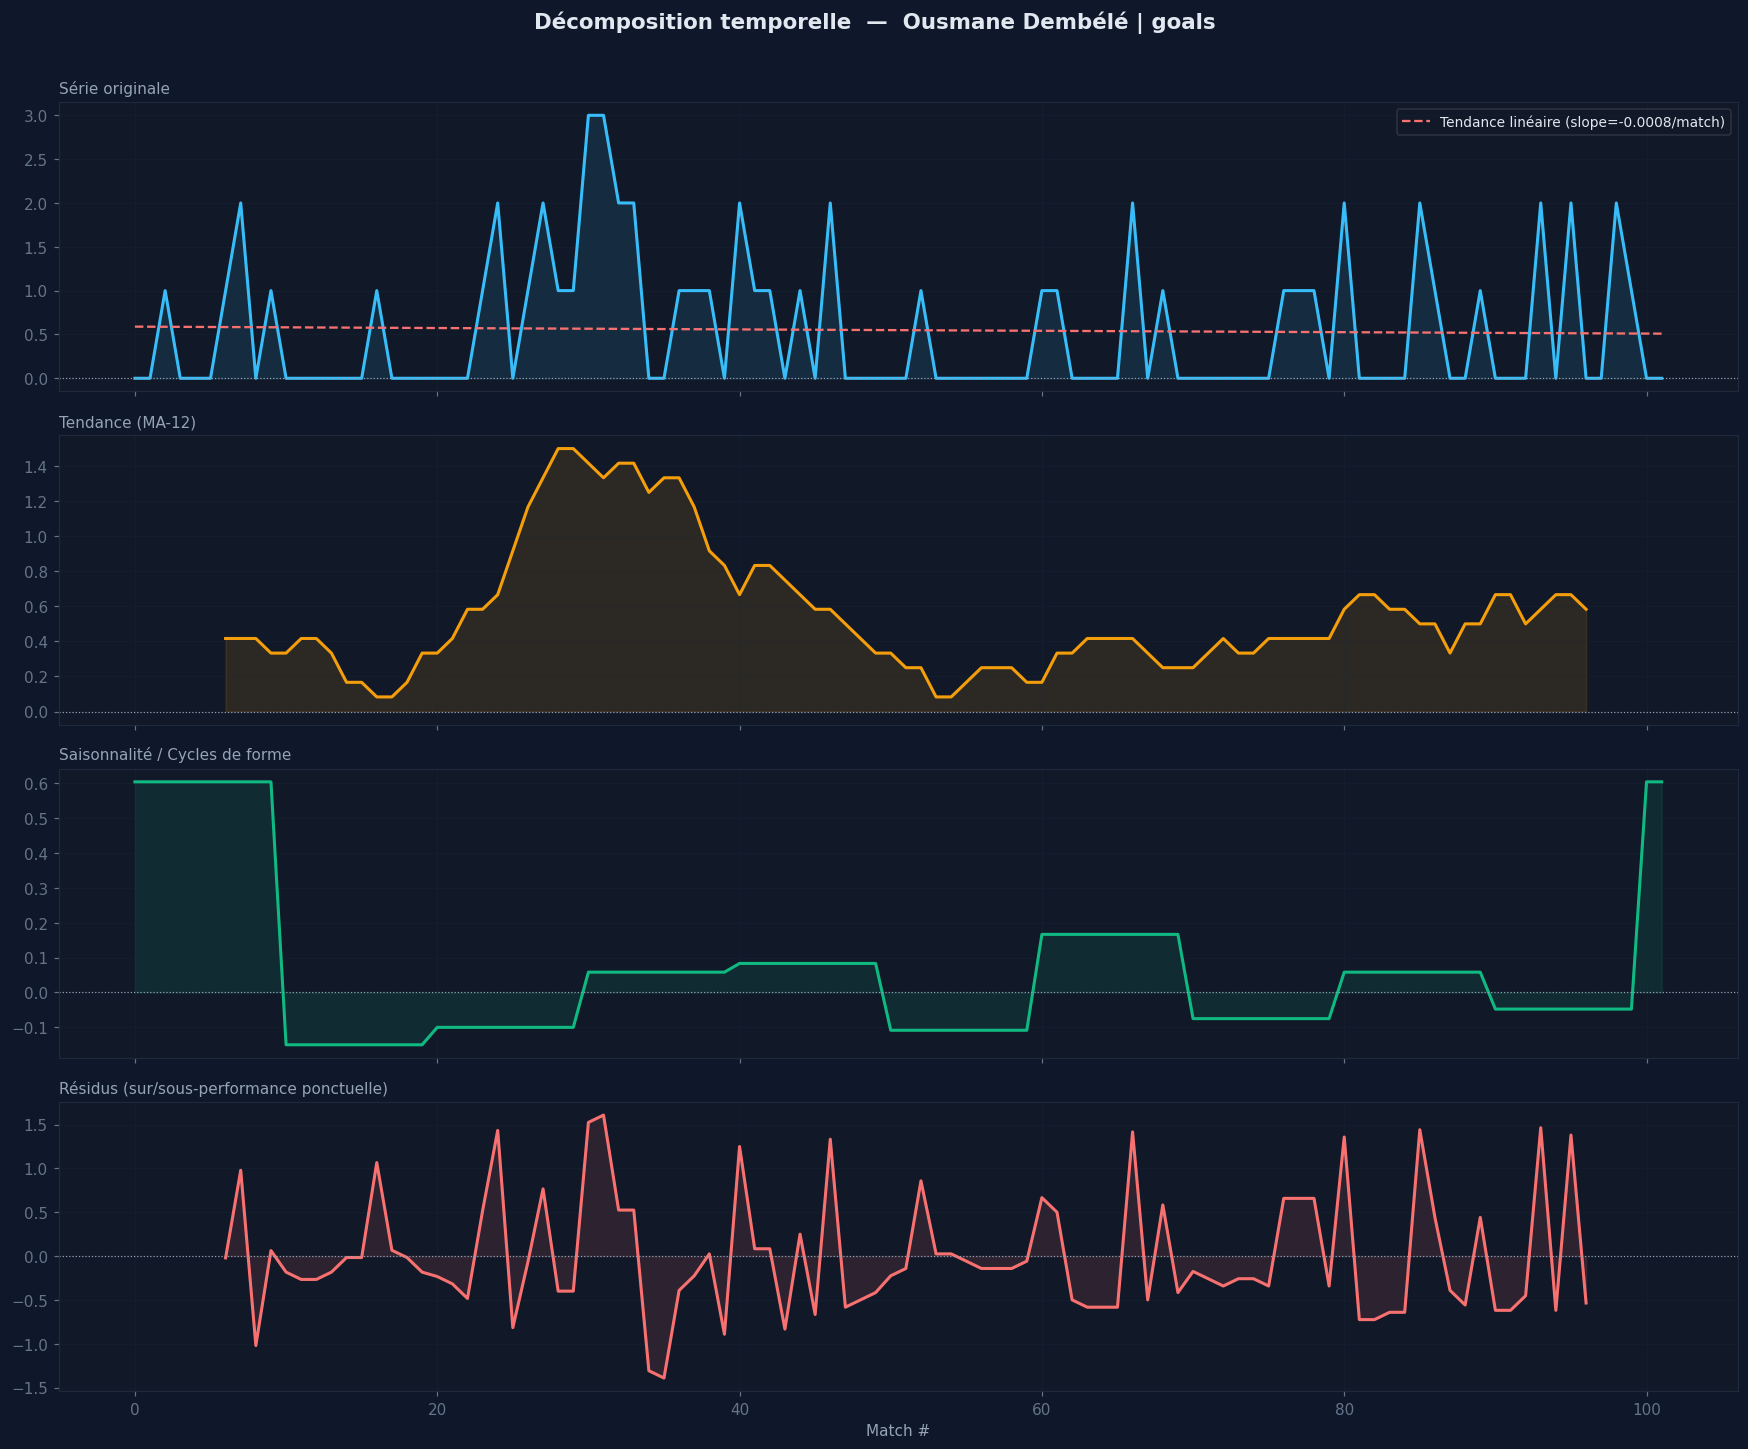


  Pente de tendance : -0.0008/match
  R² (tendance)     : 0.0009  (faible tendance linéaire)
  Volatilité résidus σ : 0.6908
  Caractère         : Stable


In [14]:
# ── 5.1 Décomposition Tendance / Saisonnalité / Résidus ──────────────────────
sc   = s.dropna().reset_index(drop=True)
n_sc = len(sc)
win  = max(3, n_sc // 8)

# Tendance : moyenne mobile centrée
trend    = sc.rolling(window=win, center=True).mean()
detrend  = sc - trend

# Saisonnalité : moyenne par groupe (proxy cycles de forme)
bsz      = max(3, n_sc // 10)
buckets  = (np.arange(n_sc) // bsz) % 10
seasonal = pd.Series(np.nan, index=range(n_sc))
for b in np.unique(buckets):
    mask = buckets == b
    seasonal[mask] = detrend[mask].mean()

residual = sc - trend - seasonal

# Régression linéaire pour la tendance
xfit = np.arange(n_sc)
slope, intercept, r_val, p_val, _ = stats.linregress(xfit, sc)

fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True)
fig.suptitle(f"Décomposition temporelle  —  {PLAYER_NAME} | {METRIC}",
             fontsize=14, fontweight="bold", y=1.01)

data_list = [(sc, BLUE, "Série originale"),
             (trend, ORANGE, f"Tendance (MA-{win})"),
             (seasonal, GREEN, "Saisonnalité / Cycles de forme"),
             (residual, RED, "Résidus (sur/sous-performance ponctuelle)")]

for ax, (data, color, title) in zip(axes, data_list):
    ax.plot(data.values, color=color, lw=2)
    ax.fill_between(range(len(data)), data.values, alpha=0.12, color=color)
    ax.axhline(0, color=GRAY, lw=0.8, ls=":")
    ax.set_title(title, color=GRAY, fontsize=10, loc="left")
    ax.grid(True, alpha=0.3)

# Ligne de tendance linéaire sur le 1er graphe
axes[0].plot(xfit, slope*xfit + intercept, color=RED, lw=1.5, ls="--",
             label=f"Tendance linéaire (slope={slope:+.4f}/match)")
axes[0].legend(framealpha=0.15, fontsize=9)
axes[-1].set_xlabel("Match #")

plt.tight_layout()
plt.savefig("/tmp/fig_decomposition.png", dpi=130, bbox_inches="tight", facecolor=DARK)
plt.show()

print(f"\n  Pente de tendance : {slope:+.4f}/match")
print(f"  R² (tendance)     : {r_val**2:.4f}  ({'forte' if r_val**2>0.3 else 'faible'} tendance linéaire)")
print(f"  Volatilité résidus σ : {residual.dropna().std():.4f}")
t_label = "Progression" if slope > 0.003 else "Régression" if slope < -0.003 else "Stable"
print(f"  Caractère         : {t_label}")


## 6. Stationnarité — Tests ADF & KPSS

In [15]:
# ── 6.1 Tests formels de stationnarité ──────────────────────────────────────
def test_stationarity(series, name=""):
    """ADF + KPSS — retourne un dict de résultats et affiche le rapport."""
    s = series.dropna()
    r = {}

    # ADF — H0 : présence d'une racine unitaire (non-stationnaire)
    adf = adfuller(s, autolag="AIC")
    r["adf_stat"]       = adf[0]
    r["adf_pvalue"]     = adf[1]
    r["adf_lags"]       = adf[2]
    r["adf_critical"]   = adf[4]
    r["adf_stationary"] = adf[1] < 0.05

    # KPSS — H0 : la série est stationnaire autour d'une constante
    kpss_res = kpss(s, regression="c", nlags="auto")
    r["kpss_stat"]       = kpss_res[0]
    r["kpss_pvalue"]     = kpss_res[1]
    r["kpss_critical"]   = kpss_res[3]
    r["kpss_stationary"] = kpss_res[1] > 0.05

    a_ok = r["adf_stationary"]; k_ok = r["kpss_stationary"]
    if a_ok and k_ok:
        verdict = "✅ STATIONNAIRE — AR/ARMA directement applicables"
    elif not a_ok and not k_ok:
        verdict = "❌ NON-STATIONNAIRE — Différenciation d≥1 requise pour ARIMA"
    elif a_ok and not k_ok:
        verdict = "🔍 Tendance déterministe probable — considérer ARIMA(d=1)"
    else:
        verdict = "🔍 Ambiguïté — vérifier la décomposition pour statuer"

    print(f"\n{'═'*58}")
    print(f"  STATIONNARITÉ — {name}")
    print(f"{'═'*58}")
    print(f"  ADF  stat={r['adf_stat']:+.4f}  p={r['adf_pvalue']:.4f}  → {'✅ Stationnaire' if a_ok else '❌ Non-stationnaire'}")
    for lv, cv in r["adf_critical"].items():
        print(f"       Valeur critique {lv} : {cv:.4f}")
    print(f"  KPSS stat={r['kpss_stat']:+.4f}  p={r['kpss_pvalue']:.4f}  → {'✅ Stationnaire' if k_ok else '❌ Non-stationnaire'}")
    print(f"  Verdict : {verdict}")
    print(f"{'═'*58}")
    return r

STAT_RES = test_stationarity(s, f"{PLAYER_NAME} | {METRIC}")



══════════════════════════════════════════════════════════
  STATIONNARITÉ — Ousmane Dembélé | goals
══════════════════════════════════════════════════════════
  ADF  stat=-8.2103  p=0.0000  → ✅ Stationnaire
       Valeur critique 1% : -3.4968
       Valeur critique 5% : -2.8906
       Valeur critique 10% : -2.5823
  KPSS stat=+0.1397  p=0.1000  → ✅ Stationnaire
  Verdict : ✅ STATIONNAIRE — AR/ARMA directement applicables
══════════════════════════════════════════════════════════


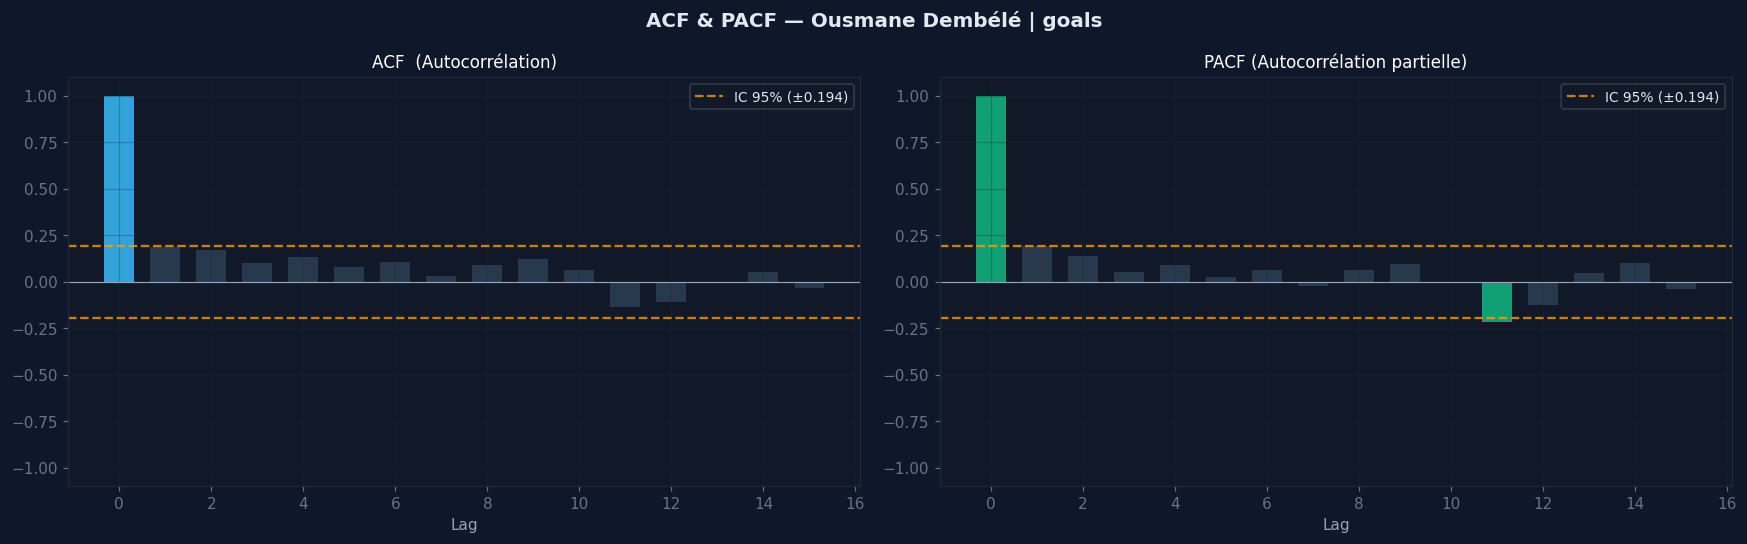

  Lags ACF significatifs : []
  → Pas d'autocorrélation significative : performances indépendantes


In [16]:
# ── 6.2 ACF & PACF ──────────────────────────────────────────────────────────
sc        = s.dropna()
max_lags  = min(15, len(sc)//2 - 1)
conf      = 1.96 / np.sqrt(len(sc))

acf_v,  acf_ci  = acf(sc,  nlags=max_lags, alpha=0.05)
pacf_v, pacf_ci = pacf(sc, nlags=max_lags, alpha=0.05)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"ACF & PACF — {PLAYER_NAME} | {METRIC}",
             fontsize=13, fontweight="bold")

for ax, vals, ci, title, color in [
    (axes[0], acf_v,  acf_ci,  "ACF  (Autocorrélation)",           BLUE),
    (axes[1], pacf_v, pacf_ci, "PACF (Autocorrélation partielle)", GREEN),
]:
    lags = range(len(vals))
    sig  = [abs(v) > conf for v in vals]
    ax.bar(lags, vals, color=[color if s else "#2d3f55" for s in sig],
           alpha=0.85, width=0.65)
    ax.axhline( conf, color=ORANGE, ls="--", lw=1.5, alpha=0.8, label=f"IC 95% (±{conf:.3f})")
    ax.axhline(-conf, color=ORANGE, ls="--", lw=1.5, alpha=0.8)
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.set_title(title, fontsize=11); ax.set_xlabel("Lag")
    ax.set_ylim(-1.1, 1.1)
    ax.legend(framealpha=0.2, fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/fig_acf_pacf.png", dpi=130, bbox_inches="tight", facecolor=DARK)
plt.show()

sig_lags = [i for i, v in enumerate(acf_v[1:], 1) if abs(v) > conf]
print(f"  Lags ACF significatifs : {sig_lags}")
if sig_lags:
    print(f"  → Cycles de forme : ~{sig_lags[0]} matchs (momentum)")
    print(f"  → Ordre AR suggéré : p ≥ {sig_lags[0]}")
else:
    print(f"  → Pas d\'autocorrélation significative : performances indépendantes")


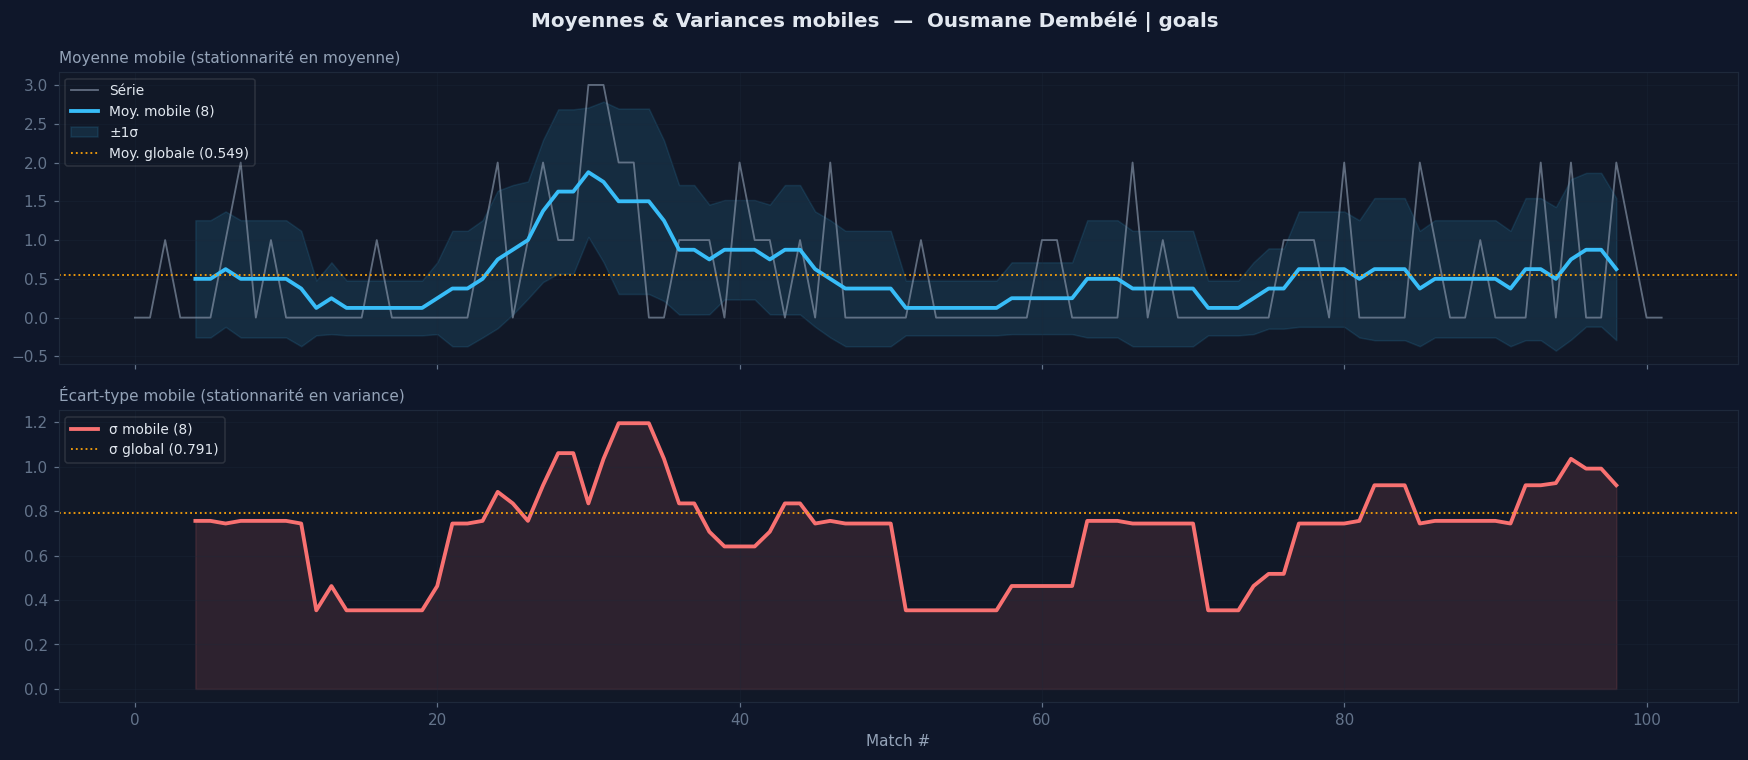

  σ 1ère moitié : 0.8641
  σ 2ème moitié : 0.7001
  Ratio         : 0.81x  (variance stable)


In [17]:
# ── 6.3 Variance mobile — Homoscédasticité ───────────────────────────────────
sc   = s.dropna().reset_index(drop=True)
win2 = min(8, len(sc)//4)

rm_mean = sc.rolling(win2, center=True).mean()
rm_std  = sc.rolling(win2, center=True).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle(f"Moyennes & Variances mobiles  —  {PLAYER_NAME} | {METRIC}",
             fontsize=13, fontweight="bold")

# Moyenne mobile
axes[0].plot(sc.values, color=GRAY, lw=1.2, alpha=0.6, label="Série")
axes[0].plot(rm_mean.values, color=BLUE, lw=2.5, label=f"Moy. mobile ({win2})")
axes[0].fill_between(range(len(sc)), rm_mean-rm_std, rm_mean+rm_std,
                     color=BLUE, alpha=0.12, label="±1σ")
axes[0].axhline(sc.mean(), color=ORANGE, ls=":", lw=1.2, label=f"Moy. globale ({sc.mean():.3f})")
axes[0].set_title("Moyenne mobile (stationnarité en moyenne)", fontsize=10, color=GRAY, loc="left")
axes[0].legend(framealpha=0.15, fontsize=9); axes[0].grid(True, alpha=0.3)

# Écart-type mobile
axes[1].plot(rm_std.values, color=RED, lw=2.5, label=f"σ mobile ({win2})")
axes[1].axhline(sc.std(), color=ORANGE, ls=":", lw=1.2, label=f"σ global ({sc.std():.3f})")
axes[1].fill_between(range(len(sc)), 0, rm_std.values, color=RED, alpha=0.12)
axes[1].set_title("Écart-type mobile (stationnarité en variance)", fontsize=10, color=GRAY, loc="left")
axes[1].legend(framealpha=0.15, fontsize=9); axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Match #")

plt.tight_layout()
plt.savefig("/tmp/fig_rolling_stats.png", dpi=130, bbox_inches="tight", facecolor=DARK)
plt.show()

# Split variance
half = len(sc)//2
s1_std, s2_std = sc[:half].std(), sc[half:].std()
ratio = s2_std / (s1_std + 1e-9)
print(f"  σ 1ère moitié : {s1_std:.4f}")
print(f"  σ 2ème moitié : {s2_std:.4f}")
print(f"  Ratio         : {ratio:.2f}x  ({'variance croissante' if ratio>1.3 else 'variance décroissante' if ratio<0.7 else 'variance stable'})")


## 7. Préparation des données


  Transformation                 ADF p-val    Stationnaire
  ───────────────────────────────────────────────────────
  Originale                      0.0000       ✅
  Différenciation d=1            0.0000       ✅
  Différenciation d=2            0.0000       ✅
  Log(1+x)                       0.0000       ✅
  Log+Diff                       0.0000       ✅


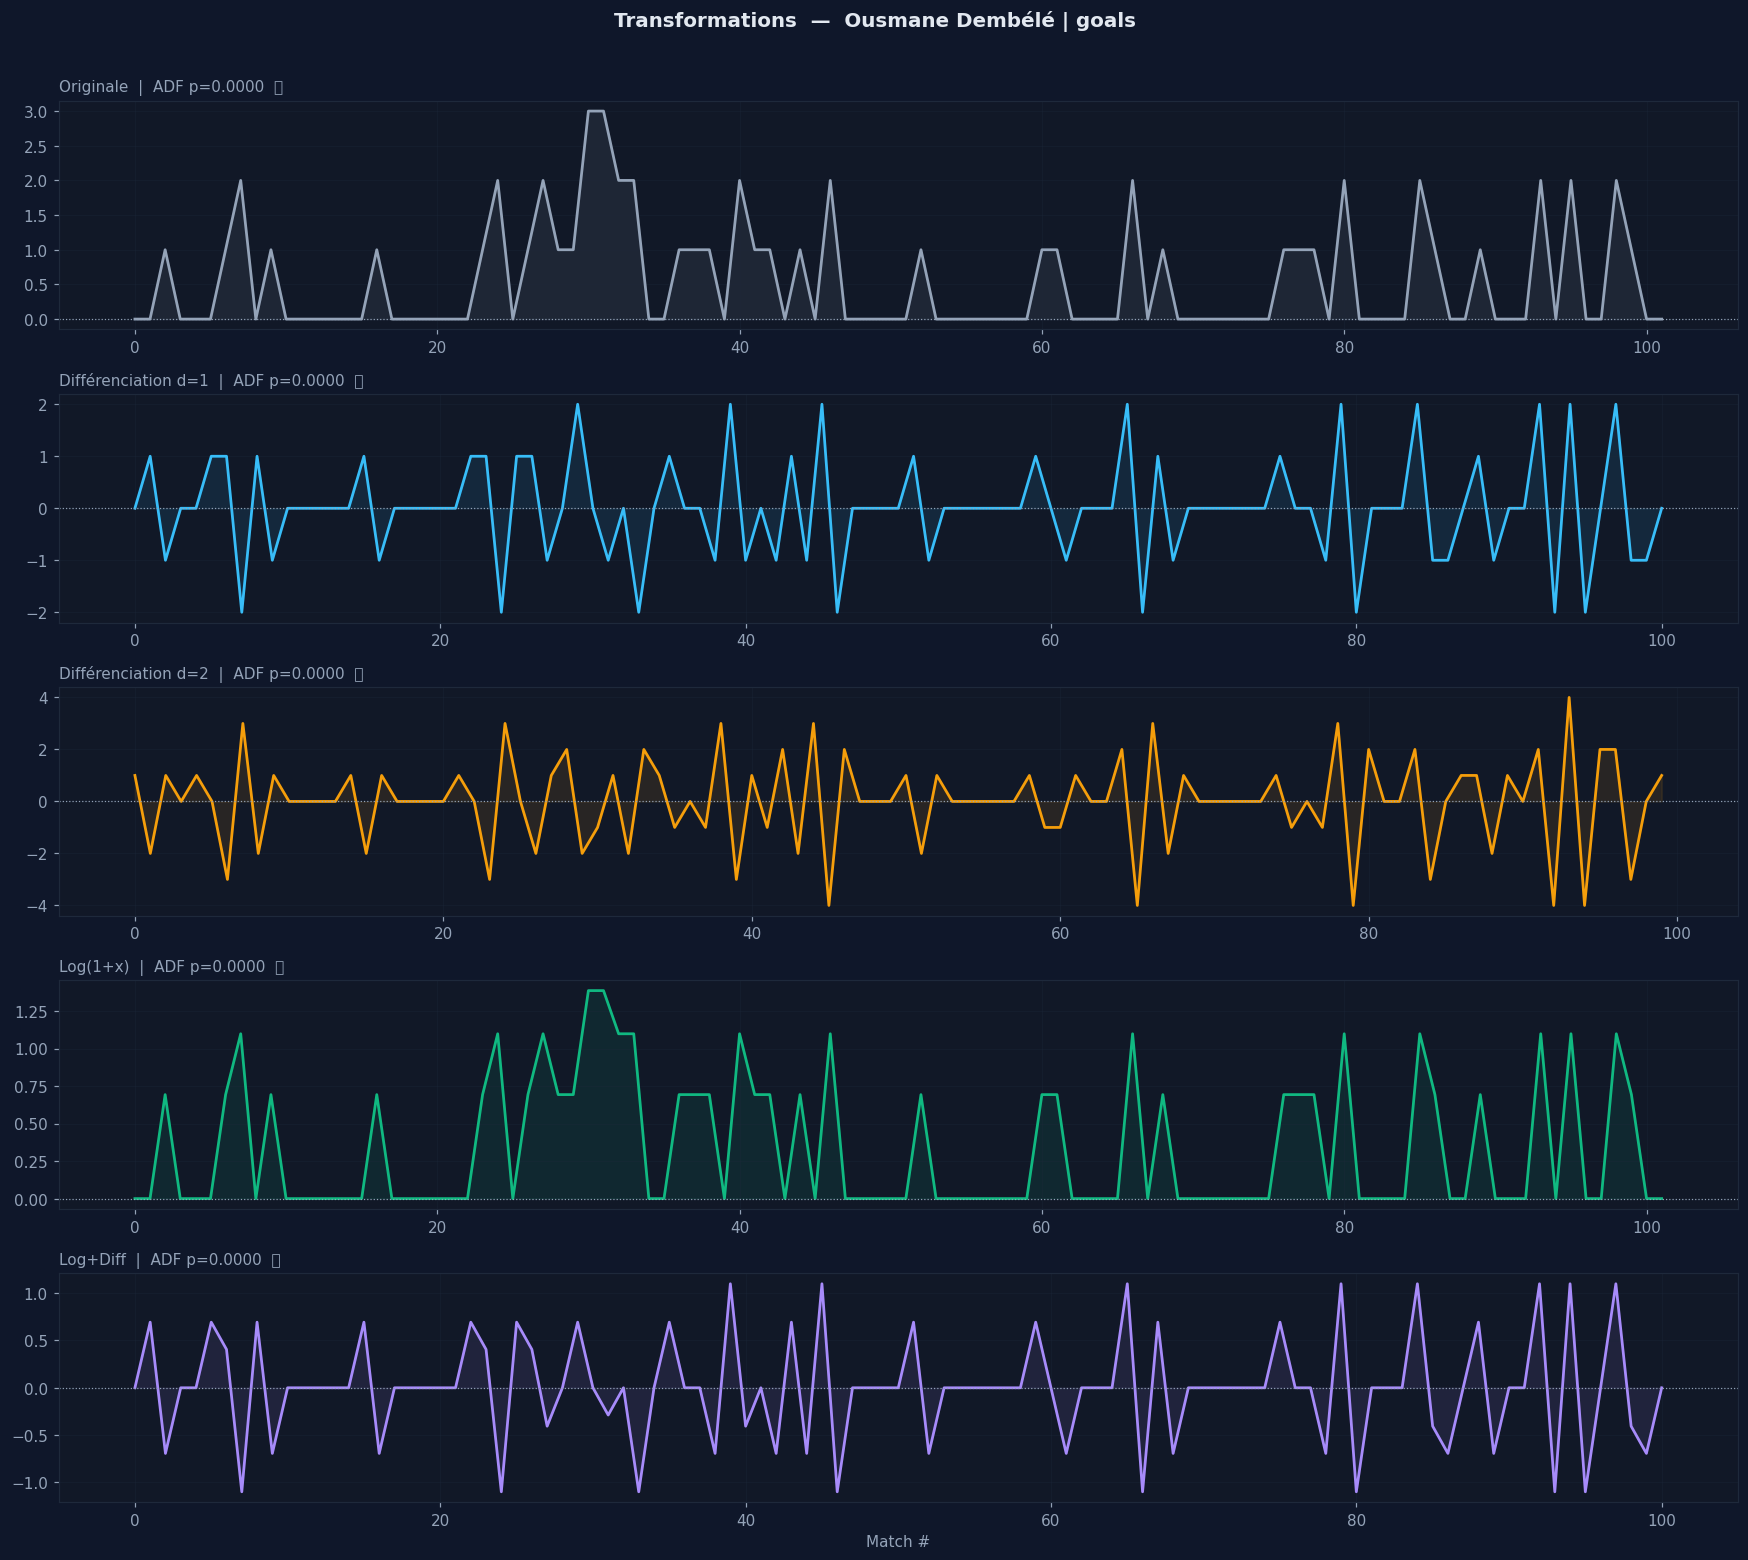

In [18]:
# ── 7.1 Transformations pour stationnariser ──────────────────────────────────
sc_orig = s.dropna().reset_index(drop=True)

transforms = [
    ("Originale",              sc_orig,                                     GRAY),
    ("Différenciation d=1",    sc_orig.diff().dropna().reset_index(drop=True), BLUE),
    ("Différenciation d=2",    sc_orig.diff().diff().dropna().reset_index(drop=True), ORANGE),
    ("Log(1+x)",               np.log1p(sc_orig.clip(lower=0)).reset_index(drop=True), GREEN),
    ("Log+Diff",               np.log1p(sc_orig.clip(lower=0)).diff().dropna().reset_index(drop=True), PURPLE),
]

fig, axes = plt.subplots(len(transforms), 1, figsize=(16, 14))
fig.suptitle(f"Transformations  —  {PLAYER_NAME} | {METRIC}",
             fontsize=13, fontweight="bold", y=1.01)

print(f"\n  {'Transformation':<30} {'ADF p-val':<12} {'Stationnaire'}")
print(f"  {'─'*55}")

for ax, (name, data, color) in zip(axes, transforms):
    ax.plot(data.values, color=color, lw=1.8)
    ax.fill_between(range(len(data)), data.values, alpha=0.10, color=color)
    ax.axhline(0, color=GRAY, lw=0.8, ls=":")
    d_clean = data.dropna()
    if len(d_clean) >= 8:
        adf_p = adfuller(d_clean, autolag="AIC")[1]
        stat_ok = adf_p < 0.05
        label = f"  |  ADF p={adf_p:.4f}  {'✅' if stat_ok else '❌'}"
        print(f"  {name:<30} {adf_p:<12.4f} {'✅' if stat_ok else '❌'}")
    else:
        label = "  |  Données insuffisantes"
    ax.set_title(f"{name}{label}", color=GRAY, fontsize=10, loc="left")
    ax.grid(True, alpha=0.3); ax.tick_params(colors=GRAY)

axes[-1].set_xlabel("Match #")
plt.tight_layout()
plt.savefig("/tmp/fig_transforms.png", dpi=130, bbox_inches="tight", facecolor=DARK)
plt.show()


In [19]:
# ── 7.2 Sélection de la transformation optimale ─────────────────────────────
# On utilise la série originale ou diff(1) selon le résultat ADF
d_optimal = 0 if STAT_RES["adf_stationary"] else 1
print(f"  ADF stationnaire : {STAT_RES['adf_stationary']}")
print(f"  → Ordre d recommandé pour ARIMA : d = {d_optimal}")

# Série de modélisation (utilisée pour AR, MA, ARMA, ARIMA, SARIMA)
s_model = s.dropna().reset_index(drop=True)
current_mean = float(s_model.mean())
print(f"\n  Série de modélisation : {len(s_model)} valeurs")
print(f"  Moyenne               : {current_mean:.4f}")


  ADF stationnaire : True
  → Ordre d recommandé pour ARIMA : d = 0

  Série de modélisation : 102 valeurs
  Moyenne               : 0.5490


## 8. Modèles de prévision

In [20]:
# ── Helper : visualisation des prévisions ────────────────────────────────────
all_metrics_list = []
all_forecasts    = {}

def plot_forecast_model(s_clean, model_name, fitted, forecast,
                        residuals=None, fore_ci=None, color=ORANGE):
    n_rows = 2 if residuals is not None else 1
    hr     = [3, 1] if n_rows == 2 else [1]
    fig, axes = plt.subplots(n_rows, 1, figsize=(16, 5*n_rows),
                              gridspec_kw={"height_ratios": hr})
    if n_rows == 1:
        axes = [axes]

    ax = axes[0]
    n  = len(s_clean)
    h  = len(forecast)
    xh = range(n)
    xf = range(n, n+h)

    ax.plot(xh, s_clean, color=GRAY, lw=1.5, alpha=0.6, label="Observations")
    ax.scatter(xh, s_clean, color=BLUE, s=20, zorder=4)

    if fitted is not None:
        fv = fitted.values if hasattr(fitted, "values") else np.array(fitted)
        ax.plot(range(len(fv)), fv, color=GREEN, lw=2.2,
                label="Ajustement in-sample", zorder=5)

    ax.axvline(n-0.5, color=GRAY, lw=1.5, ls="--", alpha=0.5)
    ax.axvspan(n-0.5, n+h-0.5, color=color, alpha=0.04)
    ax.plot(xf, forecast, color=color, lw=3, ls="--",
            marker="D", ms=8, label=f"Prévision ({model_name})", zorder=10)

    if fore_ci is not None:
        ax.fill_between(xf, fore_ci.iloc[:,0], fore_ci.iloc[:,1],
                        color=color, alpha=0.15, label="IC 95%")

    ax.axhline(s_clean.mean(), color=GRAY, ls=":", lw=1, alpha=0.6,
               label=f"Moyenne = {s_clean.mean():.3f}")
    ax.set_title(f"{model_name}  —  {PLAYER_NAME} | {METRIC}", fontsize=12)
    ax.set_ylabel(METRIC); ax.set_xlabel("Match #")
    ax.legend(framealpha=0.15, fontsize=9); ax.grid(True, alpha=0.3)

    yl = ax.get_ylim()
    ax.text(n*0.35, yl[1]*0.93, "← Historique", color=GRAY, fontsize=9, ha="center")
    ax.text(n+h*0.5, yl[1]*0.93, "Prévisions →", color=color, fontsize=9, ha="center")

    if residuals is not None:
        rv = residuals.values if hasattr(residuals,"values") else np.array(residuals)
        axes[1].bar(range(len(rv)), rv,
                    color=[GREEN if v>=0 else RED for v in rv],
                    alpha=0.75, width=0.8)
        axes[1].axhline(0, color=GRAY, lw=0.8)
        axes[1].set_title("Résidus", color=GRAY, fontsize=10, loc="left")
        axes[1].set_xlabel("Match #"); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    safe = re.sub(r"[^a-zA-Z0-9]", "_", model_name)
    plt.savefig(f"/tmp/fig_{safe}.png", dpi=130, bbox_inches="tight", facecolor=DARK)
    plt.show()

def show_metrics(model_name, aic, bic, resid):
    rv   = resid.values if hasattr(resid,"values") else np.array(resid)
    rmse = np.sqrt(np.mean(rv**2))
    mae  = np.mean(np.abs(rv))
    print(f"\n  [{model_name}]  AIC={aic:.3f}  BIC={bic:.3f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    all_metrics_list.append({"model":model_name,"aic":aic,"bic":bic,"rmse":rmse,"mae":mae})
    return rmse

print("✅ Helpers définis")


✅ Helpers définis


  Équation AR(2) :
  y(t) = 0.3920 + 0.1598·y(t-1) + 0.1402·y(t-2) + ε(t)


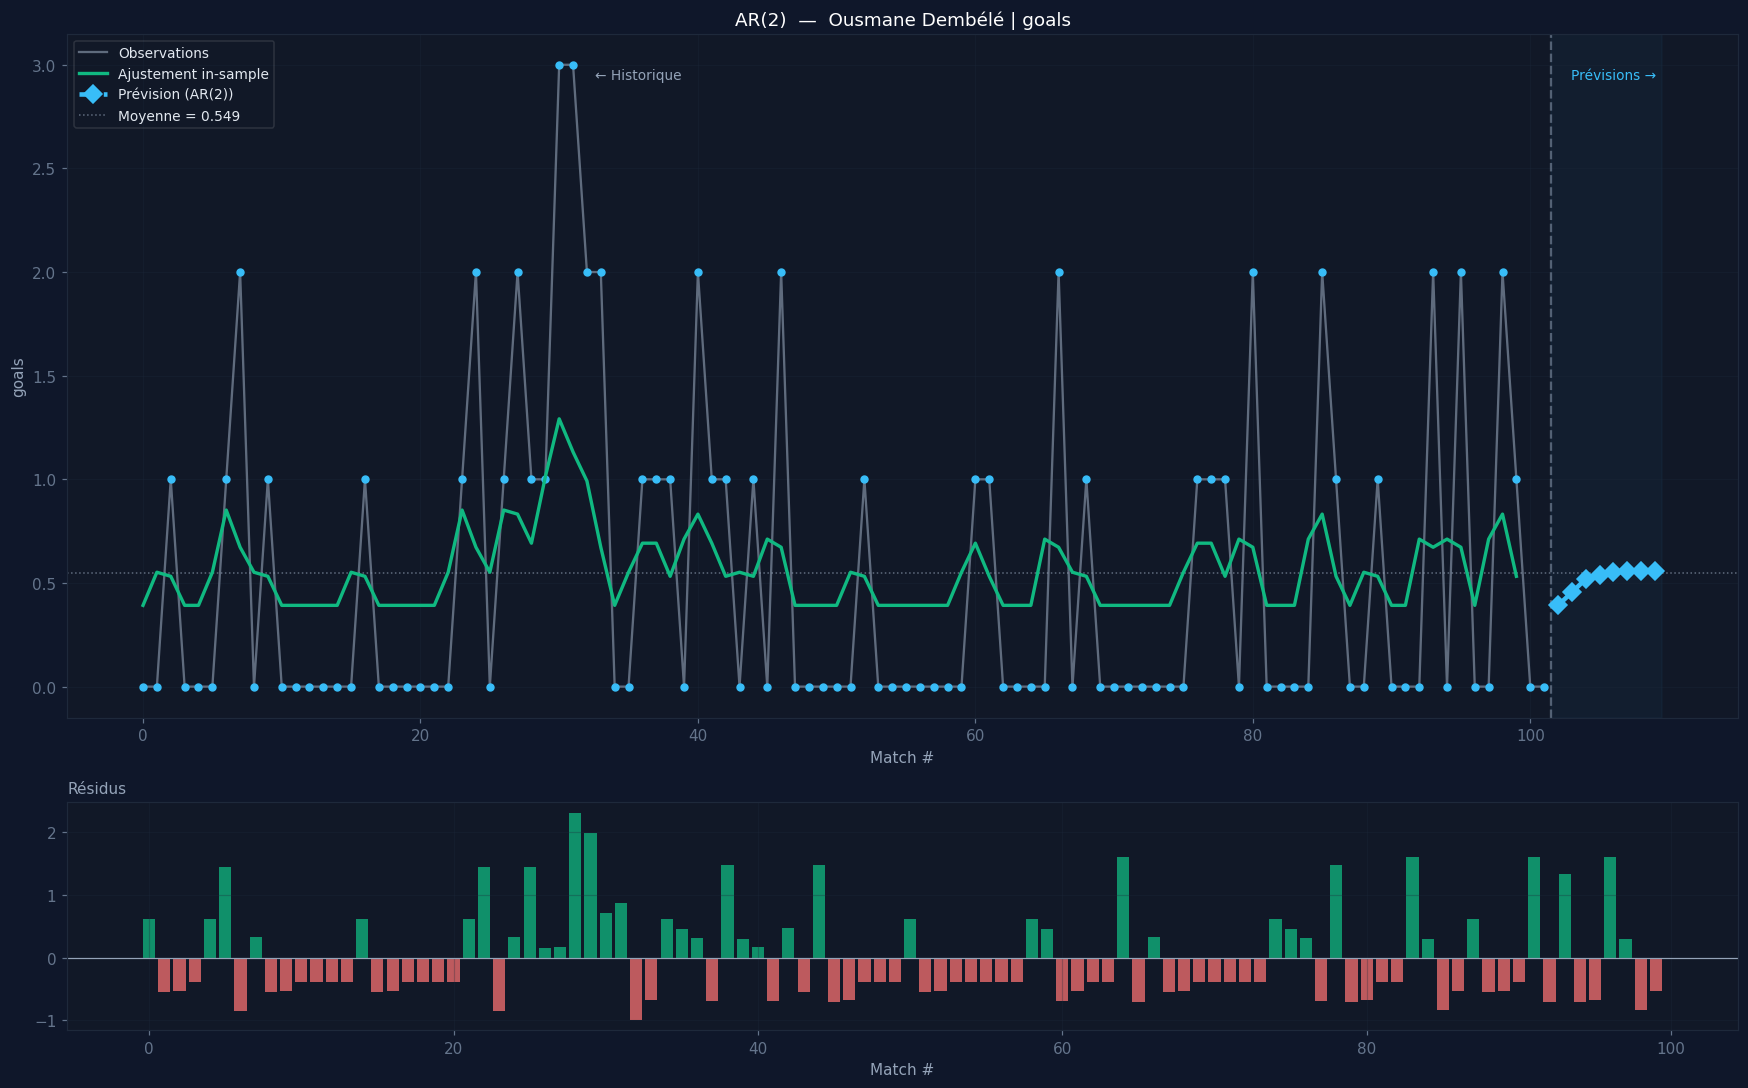


  [AR(2)]  AIC=239.513  BIC=249.933  RMSE=0.7700  MAE=0.6522

  Prévisions AR(2)  (8 matchs) :
  M+ 1 : 0.3920  (-28.6% vs moy.)
  M+ 2 : 0.4547  (-17.2% vs moy.)
  M+ 3 : 0.5196  (-5.4% vs moy.)
  M+ 4 : 0.5388  (-1.9% vs moy.)
  M+ 5 : 0.5510  (+0.4% vs moy.)
  M+ 6 : 0.5556  (+1.2% vs moy.)
  M+ 7 : 0.5580  (+1.6% vs moy.)
  M+ 8 : 0.5591  (+1.8% vs moy.)


In [21]:
# ── 8.1 AutoRégression AR(p) ─────────────────────────────────────────────────
# yₜ = c + φ₁yₜ₋₁ + φ₂yₜ₋₂ + ... + φₚyₜ₋ₚ + εₜ
#
# Chaque performance dépend des p matchs précédents.
# → Si un joueur marque souvent après un bon match : φ₁ > 0 (momentum positif)

P_AR = 2  # Modifier selon les lags ACF significatifs

model_ar = AutoReg(s_model, lags=P_AR, old_names=False).fit()
fore_ar  = model_ar.predict(start=len(s_model), end=len(s_model)+N_FORECAST-1)
resid_ar = model_ar.resid

params = model_ar.params
eq_ar  = f"y(t) = {params[0]:.4f}"
for i in range(1, min(P_AR+1, len(params))):
    eq_ar += f" + {params[i]:.4f}·y(t-{i})"
eq_ar += " + ε(t)"
print(f"  Équation AR({P_AR}) :")
print(f"  {eq_ar}")

plot_forecast_model(s_model, f"AR({P_AR})", model_ar.fittedvalues,
                    fore_ar, resid_ar, color=BLUE)
show_metrics(f"AR({P_AR})", model_ar.aic, model_ar.bic, resid_ar)
all_forecasts[f"AR({P_AR})"] = fore_ar.values

# Prévisions
print(f"\n  Prévisions AR({P_AR})  ({N_FORECAST} matchs) :")
for i, v in enumerate(fore_ar.values, 1):
    print(f"  M+{i:2d} : {v:.4f}  ({(v-current_mean)/(current_mean+1e-9)*100:+.1f}% vs moy.)")


  Équation MA(1) :
  y(t) = 0.5477 + ε(t) + 0.1478·ε(t-1)


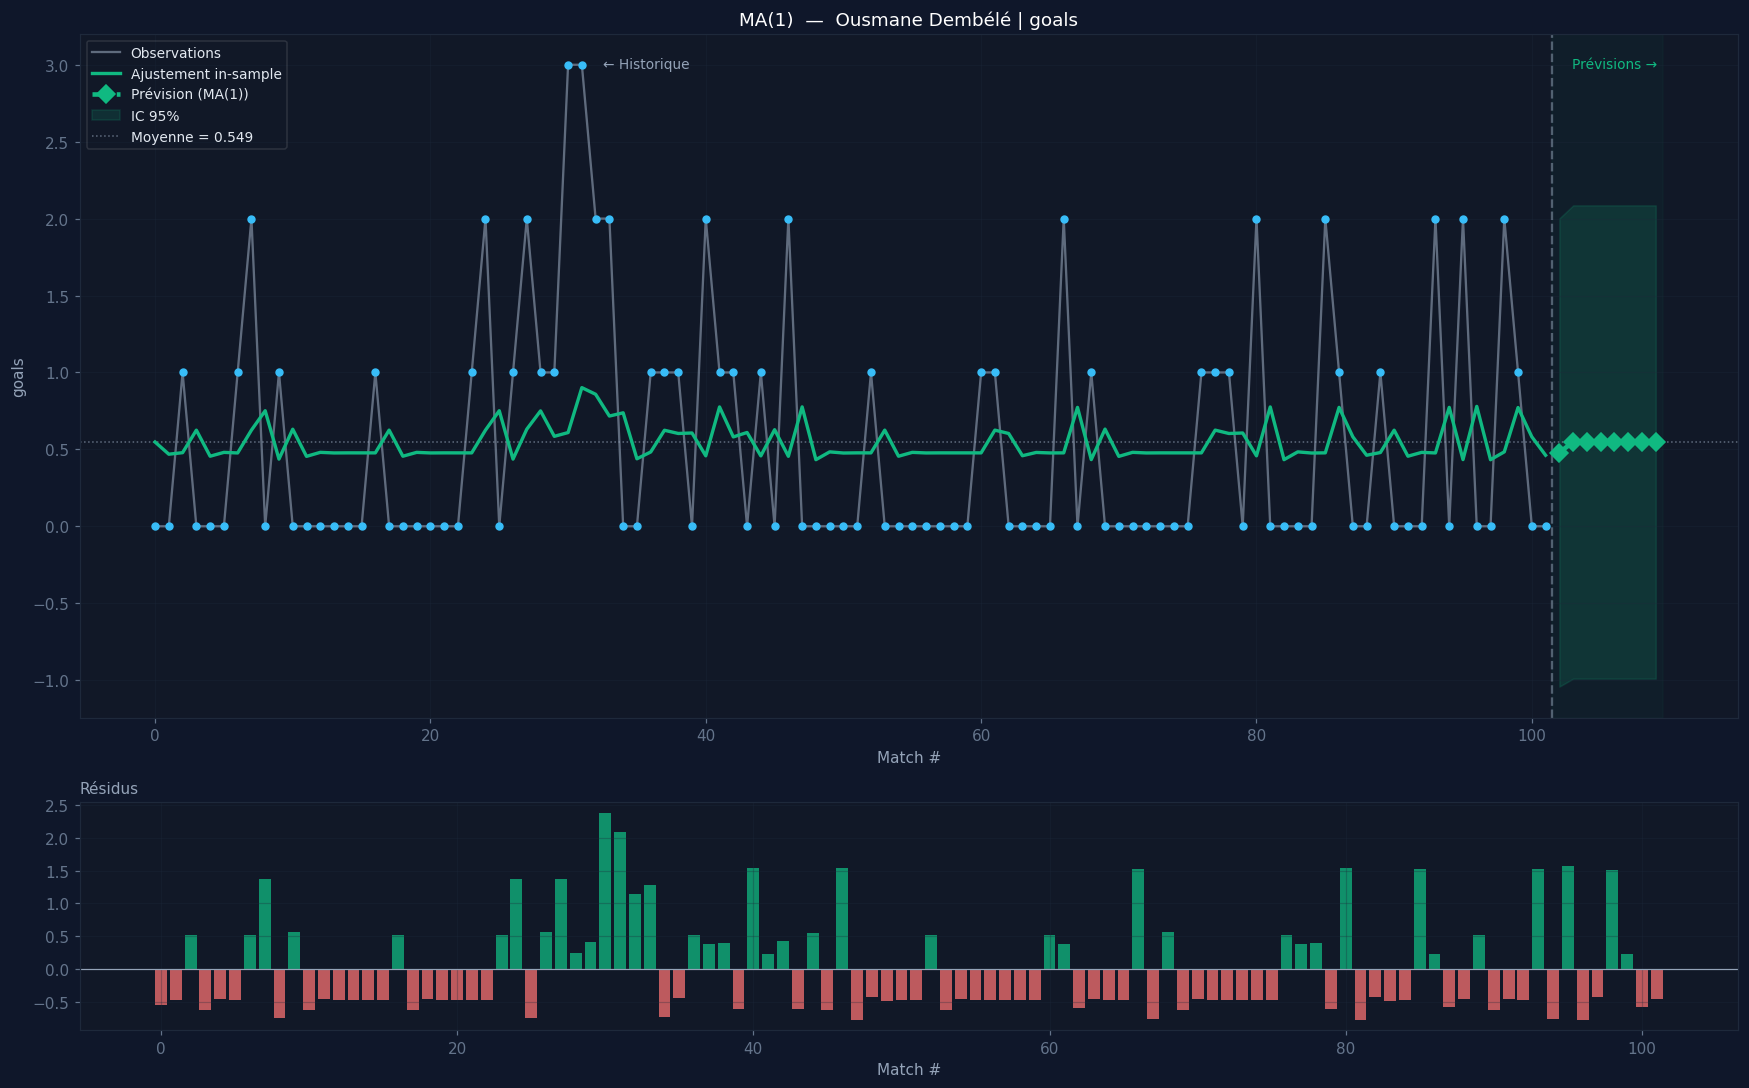


  [MA(1)]  AIC=243.857  BIC=251.732  RMSE=0.7764  MAE=0.6648

  Prévisions MA(1)  (8 matchs) :
  M+ 1 : 0.4794  (-12.7% vs moy.)
  M+ 2 : 0.5477  (-0.2% vs moy.)
  M+ 3 : 0.5477  (-0.2% vs moy.)
  M+ 4 : 0.5477  (-0.2% vs moy.)
  M+ 5 : 0.5477  (-0.2% vs moy.)
  M+ 6 : 0.5477  (-0.2% vs moy.)
  M+ 7 : 0.5477  (-0.2% vs moy.)
  M+ 8 : 0.5477  (-0.2% vs moy.)


In [22]:
# ── 8.2 Moving Average MA(q) ─────────────────────────────────────────────────
# yₜ = μ + εₜ + θ₁εₜ₋₁ + θ₂εₜ₋₂ + ... + θqεₜ₋q
#
# Chaque performance dépend des q erreurs/chocs passés.
# → Un but refusé ou une blessure légère peut affecter les matchs suivants

Q_MA = 1

model_ma = ARIMA(s_model, order=(0, 0, Q_MA)).fit()
fore_ma  = model_ma.forecast(steps=N_FORECAST)
resid_ma = model_ma.resid
fore_ci_ma = model_ma.get_forecast(steps=N_FORECAST).conf_int()

p_ma = model_ma.params
eq_ma = f"y(t) = {p_ma[0]:.4f} + ε(t)"
for i in range(1, min(Q_MA+1, len(p_ma))):
    eq_ma += f" + {p_ma[i]:.4f}·ε(t-{i})"
print(f"  Équation MA({Q_MA}) :")
print(f"  {eq_ma}")

plot_forecast_model(s_model, f"MA({Q_MA})", model_ma.fittedvalues,
                    fore_ma, resid_ma, fore_ci_ma, color=GREEN)
show_metrics(f"MA({Q_MA})", model_ma.aic, model_ma.bic, resid_ma)
all_forecasts[f"MA({Q_MA})"] = fore_ma.values

print(f"\n  Prévisions MA({Q_MA})  ({N_FORECAST} matchs) :")
for i, v in enumerate(fore_ma.values, 1):
    print(f"  M+{i:2d} : {v:.4f}  ({(v-current_mean)/(current_mean+1e-9)*100:+.1f}% vs moy.)")


  ARMA(1,1) — AIC=242.0158 | BIC=252.5156


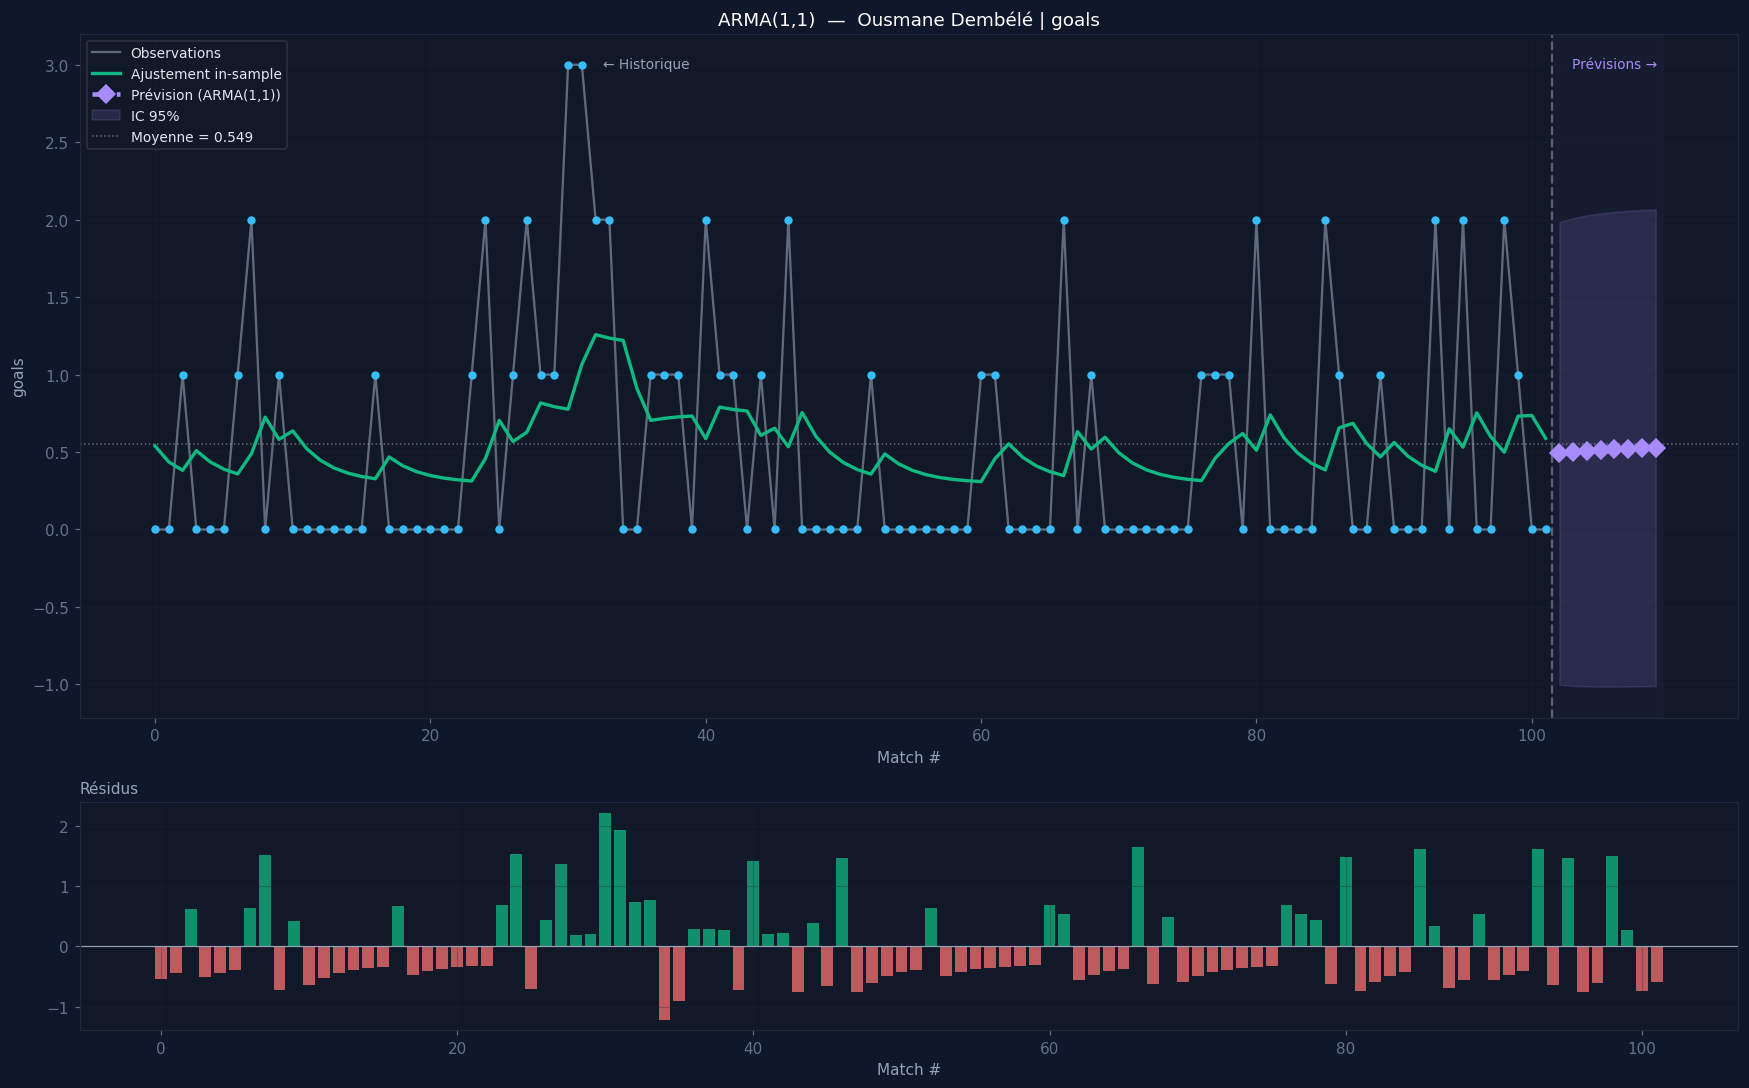


  [ARMA(1,1)]  AIC=242.016  BIC=252.516  RMSE=0.7618  MAE=0.6427

  Prévisions ARMA (8 matchs) :
  M+ 1 : 0.4912  (-10.5% vs moy.)
  M+ 2 : 0.5001  (-8.9% vs moy.)
  M+ 3 : 0.5074  (-7.6% vs moy.)
  M+ 4 : 0.5133  (-6.5% vs moy.)
  M+ 5 : 0.5181  (-5.6% vs moy.)
  M+ 6 : 0.5220  (-4.9% vs moy.)
  M+ 7 : 0.5252  (-4.3% vs moy.)
  M+ 8 : 0.5278  (-3.9% vs moy.)


In [23]:
# ── 8.3 ARMA(p,q) ────────────────────────────────────────────────────────────
# yₜ = c + φ₁yₜ₋₁+...+φₚyₜ₋ₚ + εₜ + θ₁εₜ₋₁+...+θqεₜ₋q
#
# Combine momentum (AR) et chocs passés (MA).
# → Modèle plus riche pour des joueurs dont les performances sont
#    influencées à la fois par leur récente forme ET des événements ponctuels.

P_ARMA, Q_ARMA = 1, 1

model_arma   = ARIMA(s_model, order=(P_ARMA, 0, Q_ARMA)).fit()
fore_arma    = model_arma.forecast(steps=N_FORECAST)
resid_arma   = model_arma.resid
fore_ci_arma = model_arma.get_forecast(steps=N_FORECAST).conf_int()

print(f"  ARMA({P_ARMA},{Q_ARMA}) — AIC={model_arma.aic:.4f} | BIC={model_arma.bic:.4f}")

plot_forecast_model(s_model, f"ARMA({P_ARMA},{Q_ARMA})", model_arma.fittedvalues,
                    fore_arma, resid_arma, fore_ci_arma, color=PURPLE)
show_metrics(f"ARMA({P_ARMA},{Q_ARMA})", model_arma.aic, model_arma.bic, resid_arma)
all_forecasts[f"ARMA({P_ARMA},{Q_ARMA})"] = fore_arma.values

print(f"\n  Prévisions ARMA ({N_FORECAST} matchs) :")
for i, v in enumerate(fore_arma.values, 1):
    print(f"  M+{i:2d} : {v:.4f}  ({(v-current_mean)/(current_mean+1e-9)*100:+.1f}% vs moy.)")


  ARIMA(1,0,1) — AIC=242.0158 | BIC=252.5156


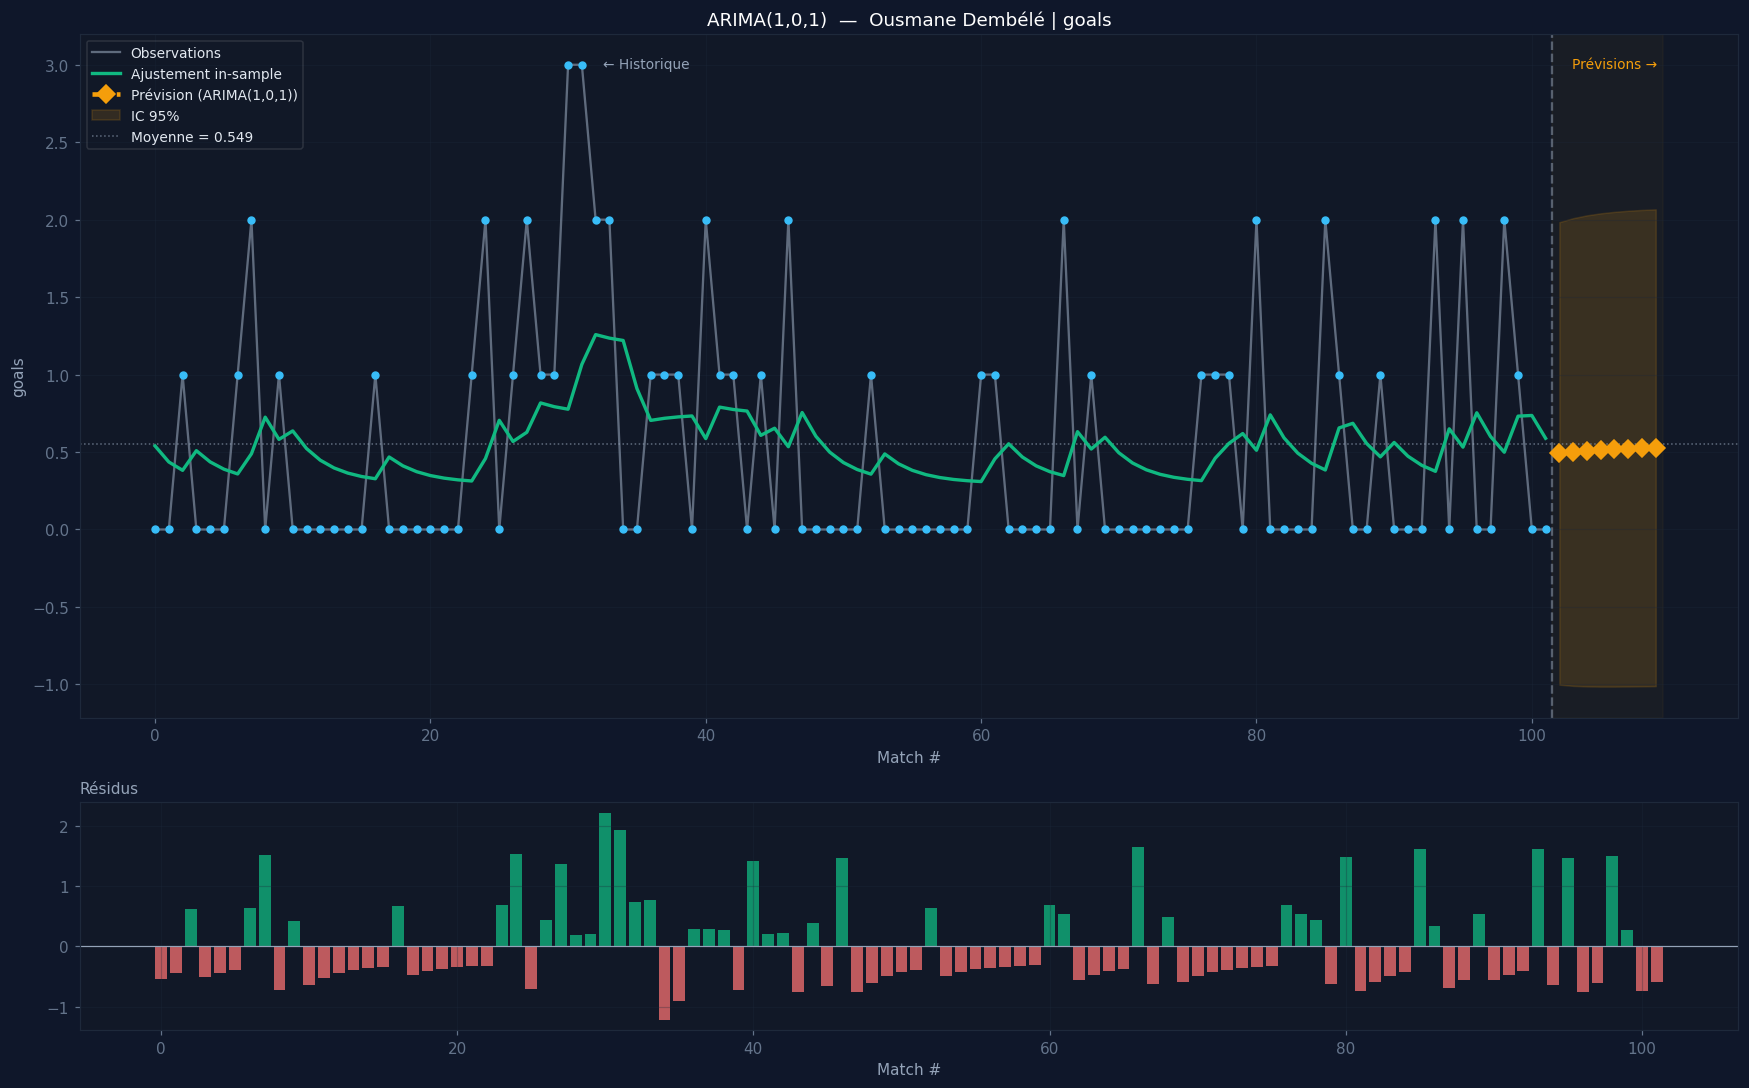


  [ARIMA(1,0,1)]  AIC=242.016  BIC=252.516  RMSE=0.7618  MAE=0.6427


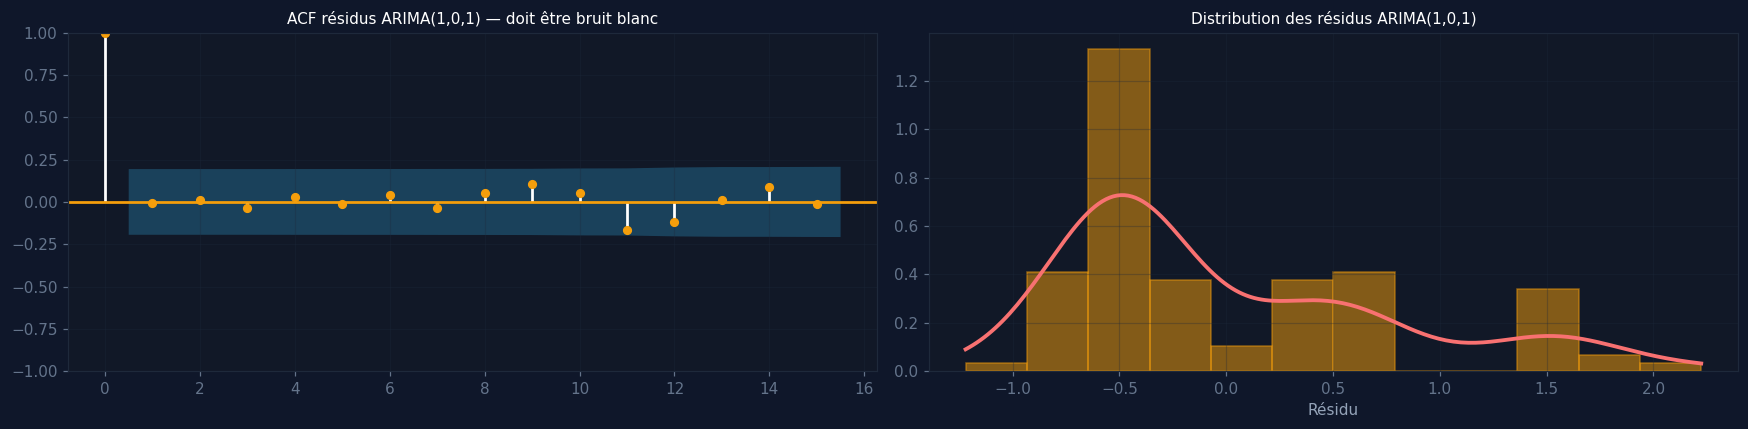


  Prévisions ARIMA(1,0,1) (8 matchs) avec IC 95% :
  M+ 1 : 0.4912  [IC: -1.002 ; 1.984]
  M+ 2 : 0.5001  [IC: -1.009 ; 2.010]
  M+ 3 : 0.5074  [IC: -1.013 ; 2.028]
  M+ 4 : 0.5133  [IC: -1.014 ; 2.041]
  M+ 5 : 0.5181  [IC: -1.014 ; 2.050]
  M+ 6 : 0.5220  [IC: -1.013 ; 2.057]
  M+ 7 : 0.5252  [IC: -1.012 ; 2.063]
  M+ 8 : 0.5278  [IC: -1.011 ; 2.067]


In [24]:
# ── 8.4 ARIMA(p,d,q) ─────────────────────────────────────────────────────────
# ARIMA = ARMA + Intégration (différenciation d fois)
# - p : ordre AR
# - d : ordre de différenciation (1 si non-stationnaire selon ADF)
# - q : ordre MA
#
# → Modèle standard pour séries non-stationnaires.
# → d=1 supprime les tendances linéaires.

P_ARIMA = 1
D_ARIMA = d_optimal   # Choisi automatiquement selon ADF (0 ou 1)
Q_ARIMA = 1

model_arima   = ARIMA(s_model, order=(P_ARIMA, D_ARIMA, Q_ARIMA)).fit()
fore_arima    = model_arima.forecast(steps=N_FORECAST)
resid_arima   = model_arima.resid
fore_ci_arima = model_arima.get_forecast(steps=N_FORECAST).conf_int()

label_arima = f"ARIMA({P_ARIMA},{D_ARIMA},{Q_ARIMA})"
print(f"  {label_arima} — AIC={model_arima.aic:.4f} | BIC={model_arima.bic:.4f}")

plot_forecast_model(s_model, label_arima, model_arima.fittedvalues,
                    fore_arima, resid_arima, fore_ci_arima, color=ORANGE)
show_metrics(label_arima, model_arima.aic, model_arima.bic, resid_arima)
all_forecasts[label_arima] = fore_arima.values

# ACF des résidus — doit être bruit blanc
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(resid_arima.dropna(), ax=axes[0],
         lags=min(15, len(resid_arima)//2-1), color=ORANGE)
axes[0].set_title(f"ACF résidus {label_arima} — doit être bruit blanc", fontsize=10)
axes[0].grid(True, alpha=0.3)

# Distribution des résidus
rv = resid_arima.dropna()
axes[1].hist(rv, bins=12, density=True, color=ORANGE, alpha=0.5, edgecolor=ORANGE, lw=0.5)
if rv.nunique() >= 2:
    kde_r = gaussian_kde(rv)
    xr    = np.linspace(rv.min(), rv.max(), 200)
    axes[1].plot(xr, kde_r(xr), color=RED, lw=2.5)
axes[1].set_title(f"Distribution des résidus {label_arima}", fontsize=10)
axes[1].set_xlabel("Résidu"); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/fig_arima_diagnostics.png", dpi=130, bbox_inches="tight", facecolor=DARK)
plt.show()

print(f"\n  Prévisions {label_arima} ({N_FORECAST} matchs) avec IC 95% :")
for i, (v, lo, hi) in enumerate(zip(fore_arima.values,
                                     fore_ci_arima.iloc[:,0],
                                     fore_ci_arima.iloc[:,1]), 1):
    print(f"  M+{i:2d} : {v:.4f}  [IC: {lo:.3f} ; {hi:.3f}]")


  SARIMA(1,0,1)(1,0,1)[5]
  AIC=235.9114 | BIC=248.6808


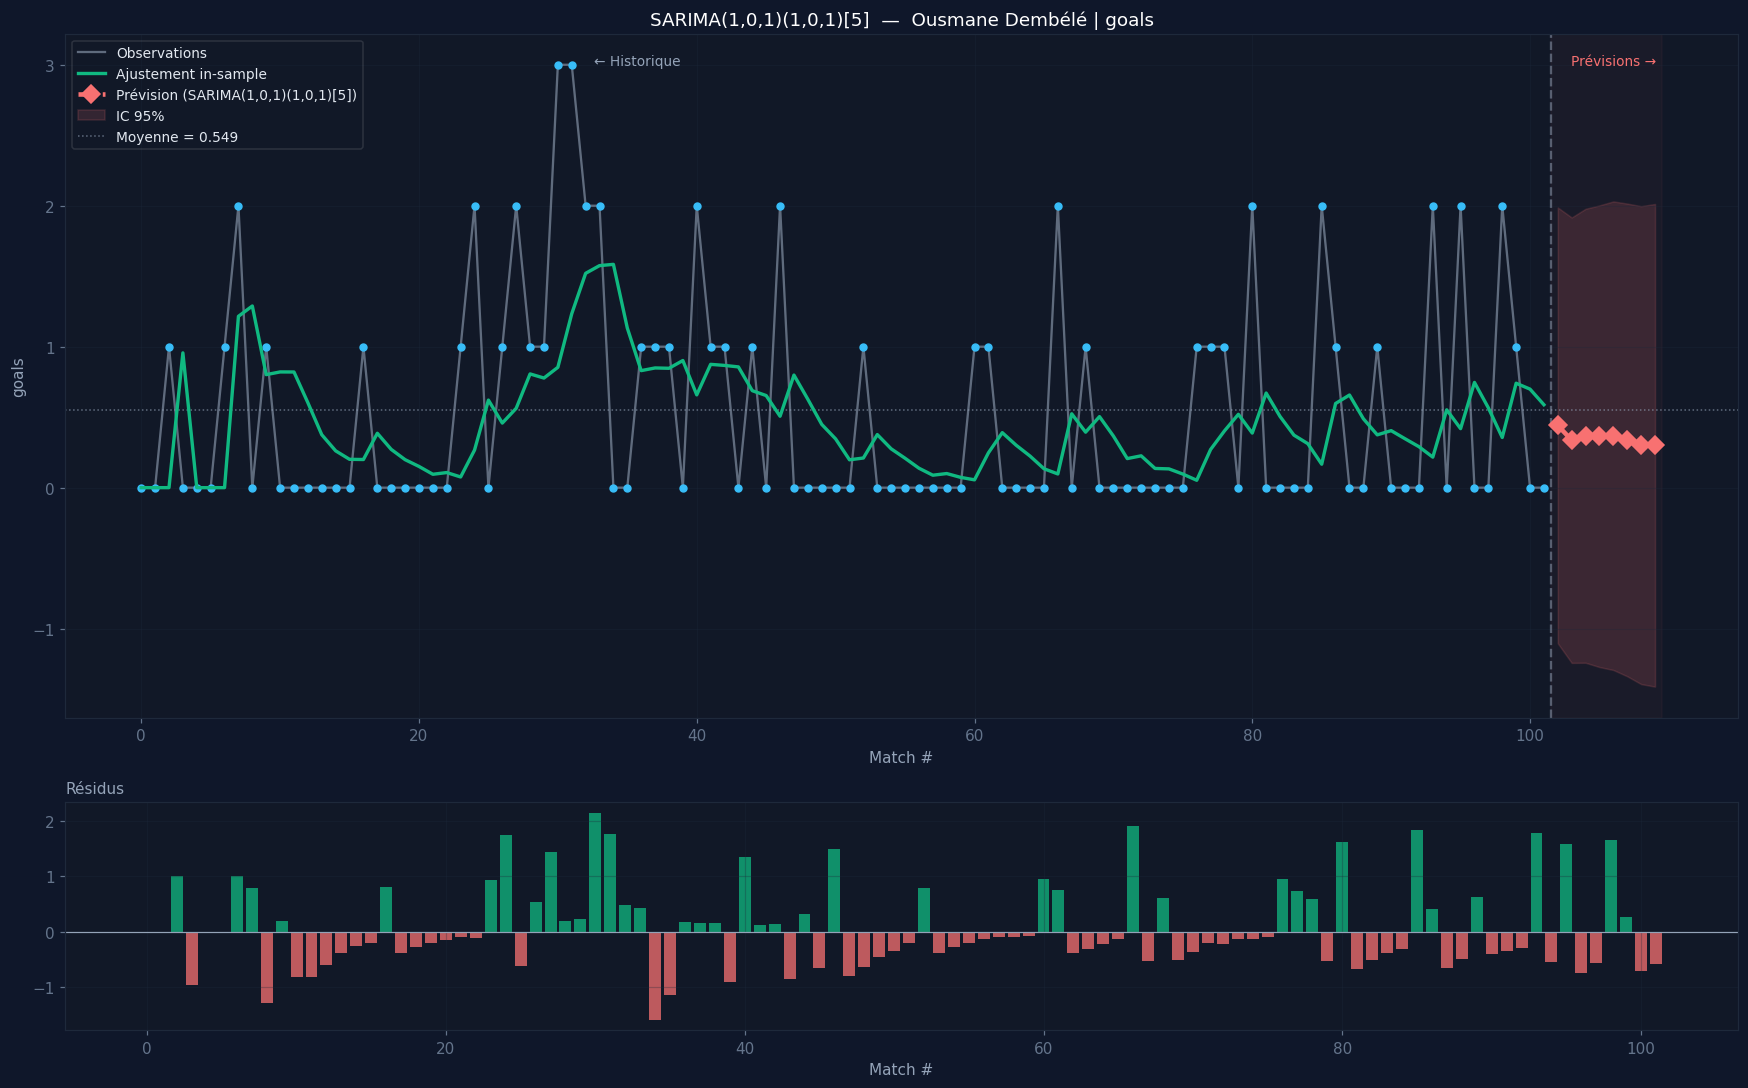


  [SARIMA(1,0,1)(1,0,1)[5]]  AIC=235.911  BIC=248.681  RMSE=0.7851  MAE=0.6026

  Prévisions SARIMA(1,0,1)(1,0,1)[5] (8 matchs) :
  M+ 1 : 0.4415  (-19.6% vs moy.)
  M+ 2 : 0.3368  (-38.7% vs moy.)
  M+ 3 : 0.3681  (-33.0% vs moy.)
  M+ 4 : 0.3649  (-33.5% vs moy.)
  M+ 5 : 0.3685  (-32.9% vs moy.)
  M+ 6 : 0.3386  (-38.3% vs moy.)
  M+ 7 : 0.3017  (-45.0% vs moy.)
  M+ 8 : 0.3004  (-45.3% vs moy.)


In [25]:
# ── 8.5 SARIMA(p,d,q)(P,D,Q)s ───────────────────────────────────────────────
# SARIMA = ARIMA + composante saisonnière
# (P,D,Q) : ordres saisonniers
# s        : période de saisonnalité
#
# Exemple : s=5 → cycle de forme de 5 matchs
#           s=7 → pattern hebdomadaire (si données quotidiennes)
#
# → Idéal si l'ACF montre des pics réguliers à des lags multiples de s.

P_SAR, D_SAR, Q_SAR = 1, D_ARIMA, 1
P_S,   D_S,   Q_S   = 1, 0,       1
S_PERIOD             = 5    # Modifier selon lags ACF significatifs

model_sarima   = SARIMAX(
    s_model,
    order=(P_SAR, D_SAR, Q_SAR),
    seasonal_order=(P_S, D_S, Q_S, S_PERIOD),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

fore_sarima    = model_sarima.forecast(steps=N_FORECAST)
resid_sarima   = model_sarima.resid
fore_ci_sarima = model_sarima.get_forecast(steps=N_FORECAST).conf_int()

label_sarima = f"SARIMA({P_SAR},{D_SAR},{Q_SAR})({P_S},{D_S},{Q_S})[{S_PERIOD}]"
print(f"  {label_sarima}")
print(f"  AIC={model_sarima.aic:.4f} | BIC={model_sarima.bic:.4f}")

plot_forecast_model(s_model, label_sarima, model_sarima.fittedvalues,
                    fore_sarima, resid_sarima, fore_ci_sarima, color=RED)
show_metrics(label_sarima, model_sarima.aic, model_sarima.bic, resid_sarima)
all_forecasts[label_sarima] = fore_sarima.values

print(f"\n  Prévisions {label_sarima} ({N_FORECAST} matchs) :")
for i, v in enumerate(fore_sarima.values, 1):
    print(f"  M+{i:2d} : {v:.4f}  ({(v-current_mean)/(current_mean+1e-9)*100:+.1f}% vs moy.)")


## 9. Comparaison & Sélection automatique du meilleur modèle

In [26]:
# ── 9.1 Tableau comparatif des modèles ───────────────────────────────────────
comp_df = pd.DataFrame(all_metrics_list).sort_values("aic").reset_index(drop=True)
comp_df.insert(0, "Rang", ["🥇","🥈","🥉"] + ["    "]*(len(comp_df)-3))

print("\n  COMPARAISON DES MODÈLES (trié par AIC)")
print(f"  {'─'*72}")
print(f"  {'Rang':<6} {'Modèle':<35} {'AIC':>10} {'BIC':>10} {'RMSE':>10} {'MAE':>8}")
print(f"  {'─'*72}")
for _, row in comp_df.iterrows():
    print(f"  {row['Rang']:<6} {row['model']:<35} {row['aic']:>10.4f} {row['bic']:>10.4f} {row['rmse']:>10.4f} {row['mae']:>8.4f}")

best_name  = comp_df.iloc[0]["model"]
best_fore  = all_forecasts[best_name]
best_rmse  = comp_df.iloc[0]["rmse"]
print(f"\n  ✅ MEILLEUR MODÈLE : {best_name}")
print(f"     AIC = {comp_df.iloc[0]['aic']:.4f} | RMSE = {best_rmse:.4f}")



  COMPARAISON DES MODÈLES (trié par AIC)
  ────────────────────────────────────────────────────────────────────────
  Rang   Modèle                                     AIC        BIC       RMSE      MAE
  ────────────────────────────────────────────────────────────────────────
  🥇      SARIMA(1,0,1)(1,0,1)[5]               235.9114   248.6808     0.7851   0.6026
  🥈      AR(2)                                 239.5127   249.9334     0.7700   0.6522
  🥉      ARIMA(1,0,1)                          242.0158   252.5156     0.7618   0.6427
         ARMA(1,1)                             242.0158   252.5156     0.7618   0.6427
         MA(1)                                 243.8574   251.7323     0.7764   0.6648

  ✅ MEILLEUR MODÈLE : SARIMA(1,0,1)(1,0,1)[5]
     AIC = 235.9114 | RMSE = 0.7851


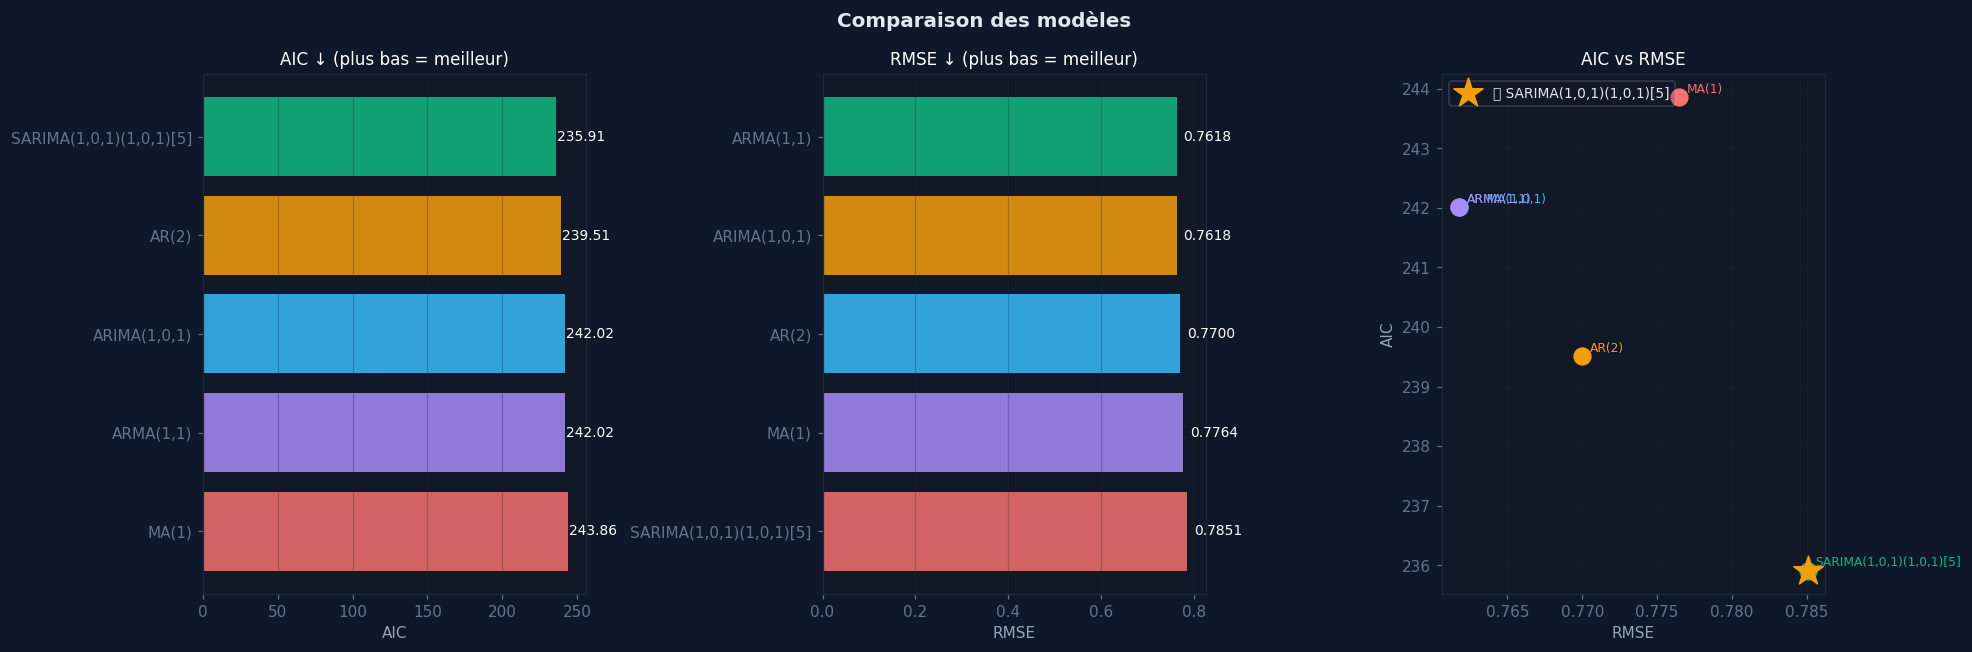

In [27]:
# ── 9.2 Visualisation comparaison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Comparaison des modèles", fontsize=13, fontweight="bold")
colors_rank = [GREEN, ORANGE, BLUE, PURPLE, RED]

# AIC
ax = axes[0]
comp_a = comp_df.sort_values("aic")
bars = ax.barh(comp_a["model"], comp_a["aic"],
               color=colors_rank[:len(comp_a)], alpha=0.85)
for bar, val in zip(bars, comp_a["aic"]):
    ax.text(val + abs(comp_a["aic"].max())*0.003,
            bar.get_y()+bar.get_height()/2,
            f"{val:.2f}", va="center", color="white", fontsize=9)
ax.set_title("AIC ↓ (plus bas = meilleur)", fontsize=11)
ax.set_xlabel("AIC"); ax.grid(True, alpha=0.3, axis="x")
ax.invert_yaxis()

# RMSE
ax = axes[1]
comp_r = comp_df.sort_values("rmse")
bars2  = ax.barh(comp_r["model"], comp_r["rmse"],
                 color=colors_rank[:len(comp_r)], alpha=0.85)
for bar, val in zip(bars2, comp_r["rmse"]):
    ax.text(val + val*0.02, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va="center", color="white", fontsize=9)
ax.set_title("RMSE ↓ (plus bas = meilleur)", fontsize=11)
ax.set_xlabel("RMSE"); ax.grid(True, alpha=0.3, axis="x")
ax.invert_yaxis()

# AIC vs RMSE scatter
ax = axes[2]
for i, row in comp_df.iterrows():
    c = colors_rank[i % len(colors_rank)]
    ax.scatter(row["rmse"], row["aic"], color=c, s=120, zorder=5)
    ax.annotate(row["model"], (row["rmse"], row["aic"]),
                textcoords="offset points", xytext=(5, 3),
                fontsize=8, color=c)
ax.set_xlabel("RMSE"); ax.set_ylabel("AIC")
ax.set_title("AIC vs RMSE", fontsize=11)
ax.grid(True, alpha=0.3)

# Étoile meilleur modèle
best_row = comp_df.iloc[0]
ax.scatter(best_row["rmse"], best_row["aic"],
           marker="*", s=400, color=ORANGE, zorder=10,
           label=f"✅ {best_name}")
ax.legend(framealpha=0.2, fontsize=9)

plt.tight_layout()
plt.savefig("/tmp/fig_model_comparison.png", dpi=130, bbox_inches="tight", facecolor=DARK)
plt.show()


## 10. Prédiction des performances futures

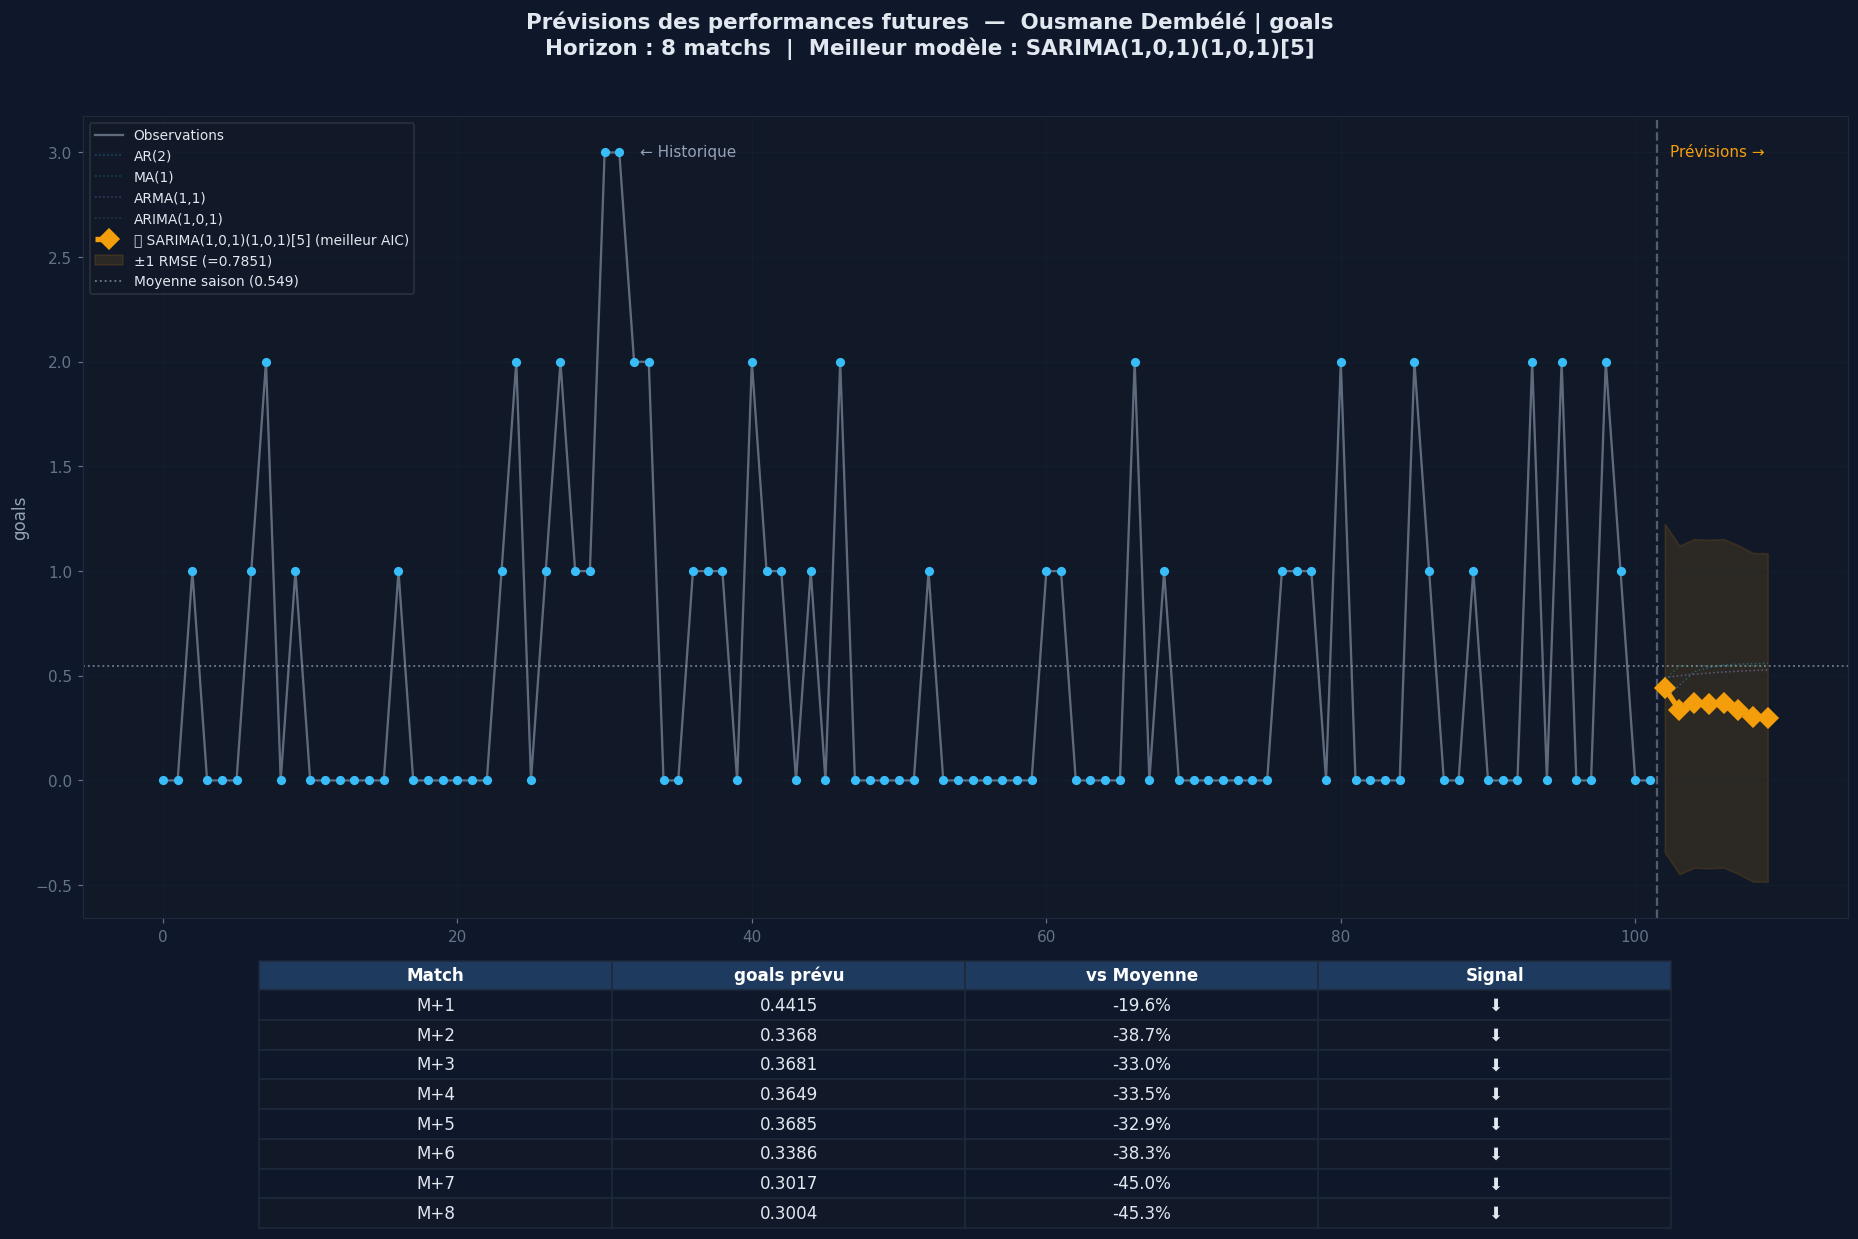


  Récapitulatif prévisions SARIMA(1,0,1)(1,0,1)[5] :
  Moyenne prévue        : 0.3526
  vs Moyenne saison     : -35.8%
  Tendance prévisions   : -31.9%


In [28]:
# ── 10.1 Graphe de prévision combiné ────────────────────────────────────────
n  = len(s_model)
xh = range(n)
xf = range(n, n+N_FORECAST)

fig, axes = plt.subplots(2, 1, figsize=(17, 11),
                          gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle(f"Prévisions des performances futures  —  {PLAYER_NAME} | {METRIC}\n"
             f"Horizon : {N_FORECAST} matchs  |  Meilleur modèle : {best_name}",
             fontsize=14, fontweight="bold", y=1.02)

ax = axes[0]

# Historique
ax.plot(xh, s_model, color=GRAY, lw=1.5, alpha=0.6, label="Observations")
ax.scatter(xh, s_model, color=BLUE, s=25, zorder=4)

# Toutes les prévisions (légères)
palette = [BLUE, GREEN, PURPLE, "#64748b"]
for i, (mname, fore) in enumerate(all_forecasts.items()):
    if mname == best_name:
        continue
    ax.plot(xf, fore, color=palette[i%len(palette)],
            lw=1, ls=":", alpha=0.35, label=mname)

# Meilleure prévision (en gras + couleur vive)
ax.plot(xf, best_fore, color=ORANGE, lw=3.5, ls="--",
        marker="D", ms=9, zorder=12, label=f"✅ {best_name} (meilleur AIC)")

# Bande ±1 RMSE
ax.fill_between(xf, best_fore-best_rmse, best_fore+best_rmse,
                color=ORANGE, alpha=0.12, label=f"±1 RMSE (={best_rmse:.4f})")

# Ligne moyenne
ax.axhline(current_mean, color=GRAY, ls=":", lw=1.2, alpha=0.7,
           label=f"Moyenne saison ({current_mean:.3f})")

# Séparateur
ax.axvline(n-0.5, color=GRAY, lw=1.5, ls="--", alpha=0.5)
yl = ax.get_ylim()
ax.text(n*0.35, yl[1]*0.94, "← Historique", color=GRAY, fontsize=10, ha="center")
ax.text(n+N_FORECAST*0.45, yl[1]*0.94, "Prévisions →", color=ORANGE, fontsize=10, ha="center")

ax.legend(framealpha=0.15, fontsize=9, loc="upper left")
ax.set_ylabel(METRIC, fontsize=11); ax.grid(True, alpha=0.3)

# Tableau des prévisions (bas)
ax2 = axes[1]
ax2.axis("off")
fore_deltas = [(v-current_mean)/(current_mean+1e-9)*100 for v in best_fore]
td = [[f"M+{i+1}", f"{v:.4f}", f"{d:+.1f}%", "⬆" if d>0 else "⬇"]
      for i, (v, d) in enumerate(zip(best_fore, fore_deltas))]

tbl = ax2.table(cellText=td,
                colLabels=["Match", f"{METRIC} prévu", "vs Moyenne", "Signal"],
                cellLoc="center", loc="center", bbox=[0.1, 0, 0.8, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1e3a5f")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor(MID if r%2==0 else "#0f172a")
        cell.set_text_props(color="#e2e8f0")
    cell.set_edgecolor("#1e293b")

plt.tight_layout()
plt.savefig("/tmp/fig_predictions_final.png", dpi=130, bbox_inches="tight", facecolor=DARK)
plt.show()

print(f"\n  Récapitulatif prévisions {best_name} :")
print(f"  Moyenne prévue        : {np.mean(best_fore):.4f}")
print(f"  vs Moyenne saison     : {np.mean(fore_deltas):+.1f}%")
print(f"  Tendance prévisions   : {(best_fore[-1]-best_fore[0])/(abs(best_fore[0])+1e-9)*100:+.1f}%")


## 11. Score de Décision d'Achat

In [29]:
# ── 11.1 Calcul des 6 critères de décision ──────────────────────────────────
s_dec    = s.dropna().reset_index(drop=True)
slope_d, _, _, _, _ = stats.linregress(np.arange(len(s_dec)), s_dec)
first5_d = float(s_dec[:5].mean()) if len(s_dec)>=5 else float(s_dec.mean())
last5_d  = float(s_dec[-5:].mean()) if len(s_dec)>=5 else float(s_dec.mean())
form_d   = (last5_d-first5_d)/(first5_d+1e-9)*100
missed_d = int(df_raw["played"].eq(False).sum())
cv_d     = float(s_dec.std()/(s_dec.mean()+1e-9))
fore_m   = float(np.mean(best_fore))
fore_tr  = (best_fore[-1]-best_fore[0])/(abs(best_fore[0])+1e-9)*100

criteria = [
    ("Tendance saison",
     f"{'Progression' if slope_d>0.003 else 'Régression' if slope_d<-0.003 else 'Stable'} ({slope_d:+.4f}/match)",
     20 if slope_d>0.005 else 15 if slope_d>0 else 8 if slope_d>-0.005 else 2),

    ("Forme récente",
     f"{form_d:+.1f}% (5 derniers vs 5 premiers)",
     20 if form_d>15 else 15 if form_d>5 else 10 if form_d>-5 else 5 if form_d>-15 else 1),

    ("Constance (CV)",
     f"CV={cv_d:.2f} ({'Très régulier' if cv_d<0.4 else 'Régulier' if cv_d<0.7 else 'Irrégulier' if cv_d<1 else 'Très irrégulier'})",
     20 if cv_d<0.4 else 15 if cv_d<0.7 else 10 if cv_d<1 else 5),

    ("Disponibilité",
     f"{missed_d} matchs manqués ({'Excellent' if missed_d<=2 else 'Bon' if missed_d<=4 else 'Risqué' if missed_d<=7 else 'Problématique'})",
     20 if missed_d<=2 else 15 if missed_d<=4 else 10 if missed_d<=7 else 3),

    ("Prévision vs Moyenne",
     f"Prévu={fore_m:.3f} vs Moy={current_mean:.3f} ({(fore_m-current_mean)/(current_mean+1e-9)*100:+.1f}%)",
     20 if fore_m>current_mean*1.1 else 15 if fore_m>=current_mean*0.95 else 8 if fore_m>=current_mean*0.8 else 3),

    ("Tendance prévisions",
     f"{'Hausse' if fore_tr>5 else 'Légère hausse' if fore_tr>0 else 'Légère baisse' if fore_tr>-10 else 'Baisse'} ({fore_tr:+.1f}%)",
     20 if fore_tr>10 else 14 if fore_tr>0 else 8 if fore_tr>-10 else 2),
]

total  = sum(c[2] for c in criteria)
max_sc = len(criteria) * 20
pct    = total / max_sc * 100

print(f"\n  {'─'*60}")
print(f"  {'Critère':<28} {'Score':<8} {'Détail'}")
print(f"  {'─'*60}")
for name, detail, score in criteria:
    bar = "█" * score + "░" * (20-score)
    print(f"  {name:<28} {score:>2}/20  {bar}  {detail}")
print(f"  {'─'*60}")
print(f"  TOTAL : {total}/{max_sc} = {pct:.1f}%")



  ────────────────────────────────────────────────────────────
  Critère                      Score    Détail
  ────────────────────────────────────────────────────────────
  Tendance saison               8/20  ████████░░░░░░░░░░░░  Stable (-0.0008/match)
  Forme récente                20/20  ████████████████████  +200.0% (5 derniers vs 5 premiers)
  Constance (CV)                5/20  █████░░░░░░░░░░░░░░░  CV=1.44 (Très irrégulier)
  Disponibilité                20/20  ████████████████████  0 matchs manqués (Excellent)
  Prévision vs Moyenne          3/20  ███░░░░░░░░░░░░░░░░░  Prévu=0.353 vs Moy=0.549 (-35.8%)
  Tendance prévisions           2/20  ██░░░░░░░░░░░░░░░░░░  Baisse (-31.9%)
  ────────────────────────────────────────────────────────────
  TOTAL : 58/120 = 48.3%


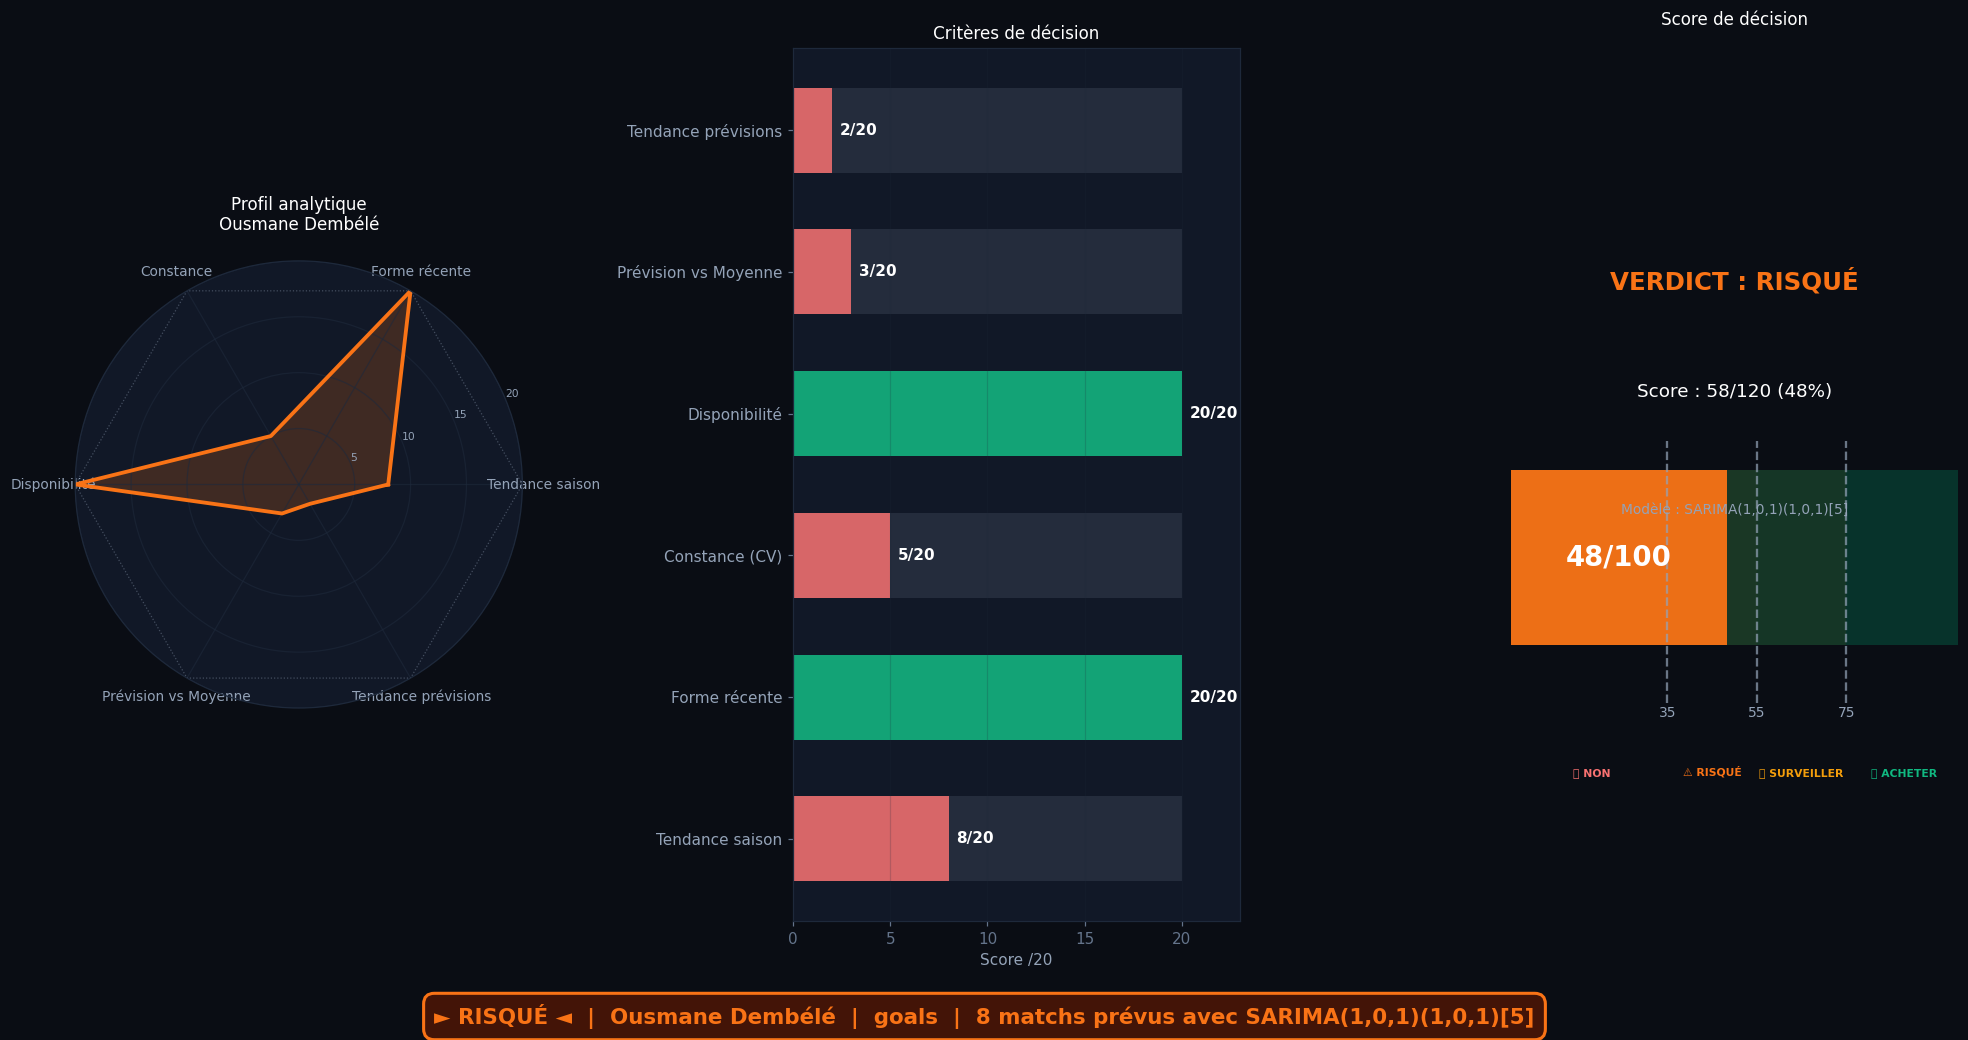


  ╔══════════════════════════════════════════════════╗
  ║  VERDICT FINAL : RISQUÉ                            ║
  ║  Score : 58/120 (48%)                              ║
  ╚══════════════════════════════════════════════════╝


In [30]:
# ── 11.2 Visualisation — Radar + Barres + Jauge ─────────────────────────────
if pct >= 75:
    verdict, vcol, bg_col = "ACHETER",         GREEN,    "#064e3b"
elif pct >= 55:
    verdict, vcol, bg_col = "SURVEILLER",      ORANGE,   "#451a03"
elif pct >= 35:
    verdict, vcol, bg_col = "RISQUÉ",          "#f97316","#431407"
else:
    verdict, vcol, bg_col = "NE PAS ACHETER",  RED,      "#450a0a"

fig = plt.figure(figsize=(18, 9))
fig.patch.set_facecolor("#0a0d14")

# ── Radar ──────────────────────────────────────────────────────────────────
ax_r  = fig.add_subplot(1, 3, 1, polar=True)
ax_r.set_facecolor(MID)
N_c   = len(criteria)
angles = [n/N_c*2*np.pi for n in range(N_c)] + [0]
scores_c = [c[2] for c in criteria] + [criteria[0][2]]
max_c    = [20]*N_c + [20]

ax_r.plot(angles, scores_c, color=vcol, lw=2.5)
ax_r.fill(angles, scores_c, color=vcol, alpha=0.20)
ax_r.plot(angles, max_c, color=GRAY, lw=0.8, ls=":", alpha=0.4)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels([c[0].split("(")[0].strip() for c in criteria],
                      color=GRAY, fontsize=9)
ax_r.set_ylim(0, 20)
ax_r.set_yticks([5,10,15,20]); ax_r.set_yticklabels(["5","10","15","20"], fontsize=7, color=GRAY)
ax_r.set_title(f"Profil analytique\n{PLAYER_NAME}", color="white", fontsize=11, pad=20)
ax_r.grid(True, color="#1e293b", alpha=0.6)
ax_r.tick_params(colors=GRAY)

# ── Barres horizontales ────────────────────────────────────────────────────
ax_b = fig.add_subplot(1, 3, 2)
ax_b.set_facecolor(MID)
y_pos = range(N_c)
cols_b = [GREEN if s>=15 else ORANGE if s>=10 else RED for _,_,s in criteria]
ax_b.barh(y_pos, [20]*N_c, color=GRAY, alpha=0.15, height=0.6)
bars_b = ax_b.barh(y_pos, [c[2] for c in criteria],
                   color=cols_b, alpha=0.85, height=0.6)
for bar, (_, _, score) in zip(bars_b, criteria):
    ax_b.text(score+0.4, bar.get_y()+bar.get_height()/2,
              f"{score}/20", va="center", color="white", fontsize=10, fontweight="bold")
ax_b.set_yticks(y_pos)
ax_b.set_yticklabels([c[0] for c in criteria], color=GRAY, fontsize=10)
ax_b.set_xlim(0, 23); ax_b.set_xlabel("Score /20", color=GRAY)
ax_b.set_title("Critères de décision", color="white", fontsize=11)
ax_b.grid(True, alpha=0.2, axis="x")

# ── Jauge (simulée) ────────────────────────────────────────────────────────
ax_g = fig.add_subplot(1, 3, 3)
ax_g.set_facecolor(MID)
ax_g.set_xlim(0, 100); ax_g.set_ylim(0, 60)
ax_g.axis("off")

# Fond de jauge
for limit, color_fill in [(35, "#450a0a"), (55, "#431407"), (75, "#451a03"), (100, "#064e3b")]:
    ax_g.barh(25, limit, height=12, color=color_fill, alpha=0.6, left=0)

# Barre de score
ax_g.barh(25, pct, height=12, color=vcol, alpha=0.95, left=0)

# Marqueurs
for v, lbl in [(35,"35"), (55,"55"), (75,"75")]:
    ax_g.axvline(v, ymin=0.25, ymax=0.55, color=GRAY, lw=1.5, ls="--", alpha=0.7)
    ax_g.text(v, 14, lbl, color=GRAY, ha="center", fontsize=9)

ax_g.text(pct/2, 25, f"{pct:.0f}/100", ha="center", va="center",
          color="white", fontsize=18, fontweight="bold")
ax_g.text(50, 44, f"VERDICT : {verdict}", ha="center", va="center",
          color=vcol, fontsize=16, fontweight="bold")
ax_g.text(50, 36, f"Score : {total}/{max_sc} ({pct:.0f}%)", ha="center",
          color="white", fontsize=12)
ax_g.text(50, 28, f"Modèle : {best_name}", ha="center", color=GRAY, fontsize=9)

# Zones labels
for x, lbl, c in [(18, "❌ NON", RED), (45, "⚠️ RISQUÉ", "#f97316"),
                   (65, "🟡 SURVEILLER", ORANGE), (88, "✅ ACHETER", GREEN)]:
    ax_g.text(x, 10, lbl, ha="center", color=c, fontsize=7, fontweight="bold")

ax_g.set_title("Score de décision", color="white", fontsize=11, pad=15)

# Verdict bannière
fig.text(0.5, -0.04, f"► {verdict} ◄  |  {PLAYER_NAME}  |  {METRIC}  |  {N_FORECAST} matchs prévus avec {best_name}",
         ha="center", fontsize=14, fontweight="bold", color=vcol,
         bbox=dict(boxstyle="round,pad=0.5", facecolor=bg_col, edgecolor=vcol, lw=2))

plt.tight_layout()
plt.savefig("/tmp/fig_decision_score.png", dpi=130, bbox_inches="tight", facecolor="#0a0d14")
plt.show()

print(f"\n  ╔{'═'*50}╗")
print(f"  ║  VERDICT FINAL : {verdict:<34}║")
print(f"  ║  Score : {total}/{max_sc} ({pct:.0f}%)                              ║")
print(f"  ╚{'═'*50}╝")


## 12. Rapport de synthèse & Export

In [31]:
# ── 12.1 Génération du rapport complet ───────────────────────────────────────
rapport = f"""
{'='*65}
RAPPORT DE DÉCISION DE TRANSFERT — FOOTBALL ANALYTICS PRO
{'='*65}
Joueur    : {PLAYER_NAME}
Saison    : {SEASON}
Métrique  : {METRIC}
Date      : {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}
{'='*65}

1. APERÇU DE LA SAISON
   Matchs joués    : {len(s_dec)}
   Matchs manqués  : {missed_d}
   Moyenne saison  : {s_dec.mean():.4f}
   Médiane         : {s_dec.median():.4f}
   Écart-type      : {s_dec.std():.4f}
   Coeff. variation: {cv_d:.4f}

2. TENDANCE & FORME
   Pente de tendance  : {slope_d:+.4f}/match
   Caractère          : {'Progression' if slope_d>0.003 else 'Régression' if slope_d<-0.003 else 'Stable'}
   Forme début saison : {first5_d:.4f}
   Forme récente      : {last5_d:.4f} ({form_d:+.1f}%)

3. STATIONNARITÉ
   ADF  : {'Stationnaire' if STAT_RES['adf_stationary'] else 'Non-stationnaire'} (p={STAT_RES['adf_pvalue']:.4f})
   KPSS : {'Stationnaire' if STAT_RES['kpss_stationary'] else 'Non-stationnaire'} (p={STAT_RES['kpss_pvalue']:.4f})
   → Ordre d recommandé : d = {d_optimal}

4. MODÉLISATION — COMPARAISON
{chr(10).join(f"   {row['model']:<35} AIC={row['aic']:.3f}  RMSE={row['rmse']:.4f}" for _,row in comp_df.iterrows())}

   Meilleur modèle : {best_name} (AIC={comp_df.iloc[0]['aic']:.4f} | RMSE={best_rmse:.4f})

5. PRÉVISIONS — {N_FORECAST} PROCHAINS MATCHS ({best_name})
{chr(10).join(f"   M+{i+1:2d} : {v:.4f}  ({d:+.1f}% vs moy.)" for i,(v,d) in enumerate(zip(best_fore, fore_deltas)))}

6. SCORE DE DÉCISION
{chr(10).join(f"   {n:<28} : {sc:>2}/20  {d}" for n,d,sc in criteria)}
   {'─'*55}
   TOTAL : {total}/{max_sc} = {pct:.1f}%

7. VERDICT FINAL
   ► {verdict} ◄

   {'Profil solide — progression, constance, prévisions favorables.' if verdict=='ACHETER' else 'Profil intéressant mais incertain — négocier le prix.' if verdict=='SURVEILLER' else 'Signaux préoccupants — attendre avant d investir.' if verdict=='RISQUÉ' else 'Profil trop incertain — ne pas acquérir.'}

{'='*65}
"""

print(rapport)

# Sauvegarde
safe_name = re.sub(r"[^a-zA-Z0-9]", "_", PLAYER_NAME)
path = f"/tmp/rapport_{safe_name}_{METRIC}.txt"
with open(path, "w", encoding="utf-8") as f:
    f.write(rapport)
print(f"  📄 Rapport sauvegardé : {path}")



RAPPORT DE DÉCISION DE TRANSFERT — FOOTBALL ANALYTICS PRO
Joueur    : Ousmane Dembélé
Saison    : 2024-2026
Métrique  : goals
Date      : 2026-05-26 11:47

1. APERÇU DE LA SAISON
   Matchs joués    : 102
   Matchs manqués  : 0
   Moyenne saison  : 0.5490
   Médiane         : 0.0000
   Écart-type      : 0.7914
   Coeff. variation: 1.4414

2. TENDANCE & FORME
   Pente de tendance  : -0.0008/match
   Caractère          : Stable
   Forme début saison : 0.2000
   Forme récente      : 0.6000 (+200.0%)

3. STATIONNARITÉ
   ADF  : Stationnaire (p=0.0000)
   KPSS : Stationnaire (p=0.1000)
   → Ordre d recommandé : d = 0

4. MODÉLISATION — COMPARAISON
   SARIMA(1,0,1)(1,0,1)[5]             AIC=235.911  RMSE=0.7851
   AR(2)                               AIC=239.513  RMSE=0.7700
   ARIMA(1,0,1)                        AIC=242.016  RMSE=0.7618
   ARMA(1,1)                           AIC=242.016  RMSE=0.7618
   MA(1)                               AIC=243.857  RMSE=0.7764

   Meilleur modèle : SARIMA(

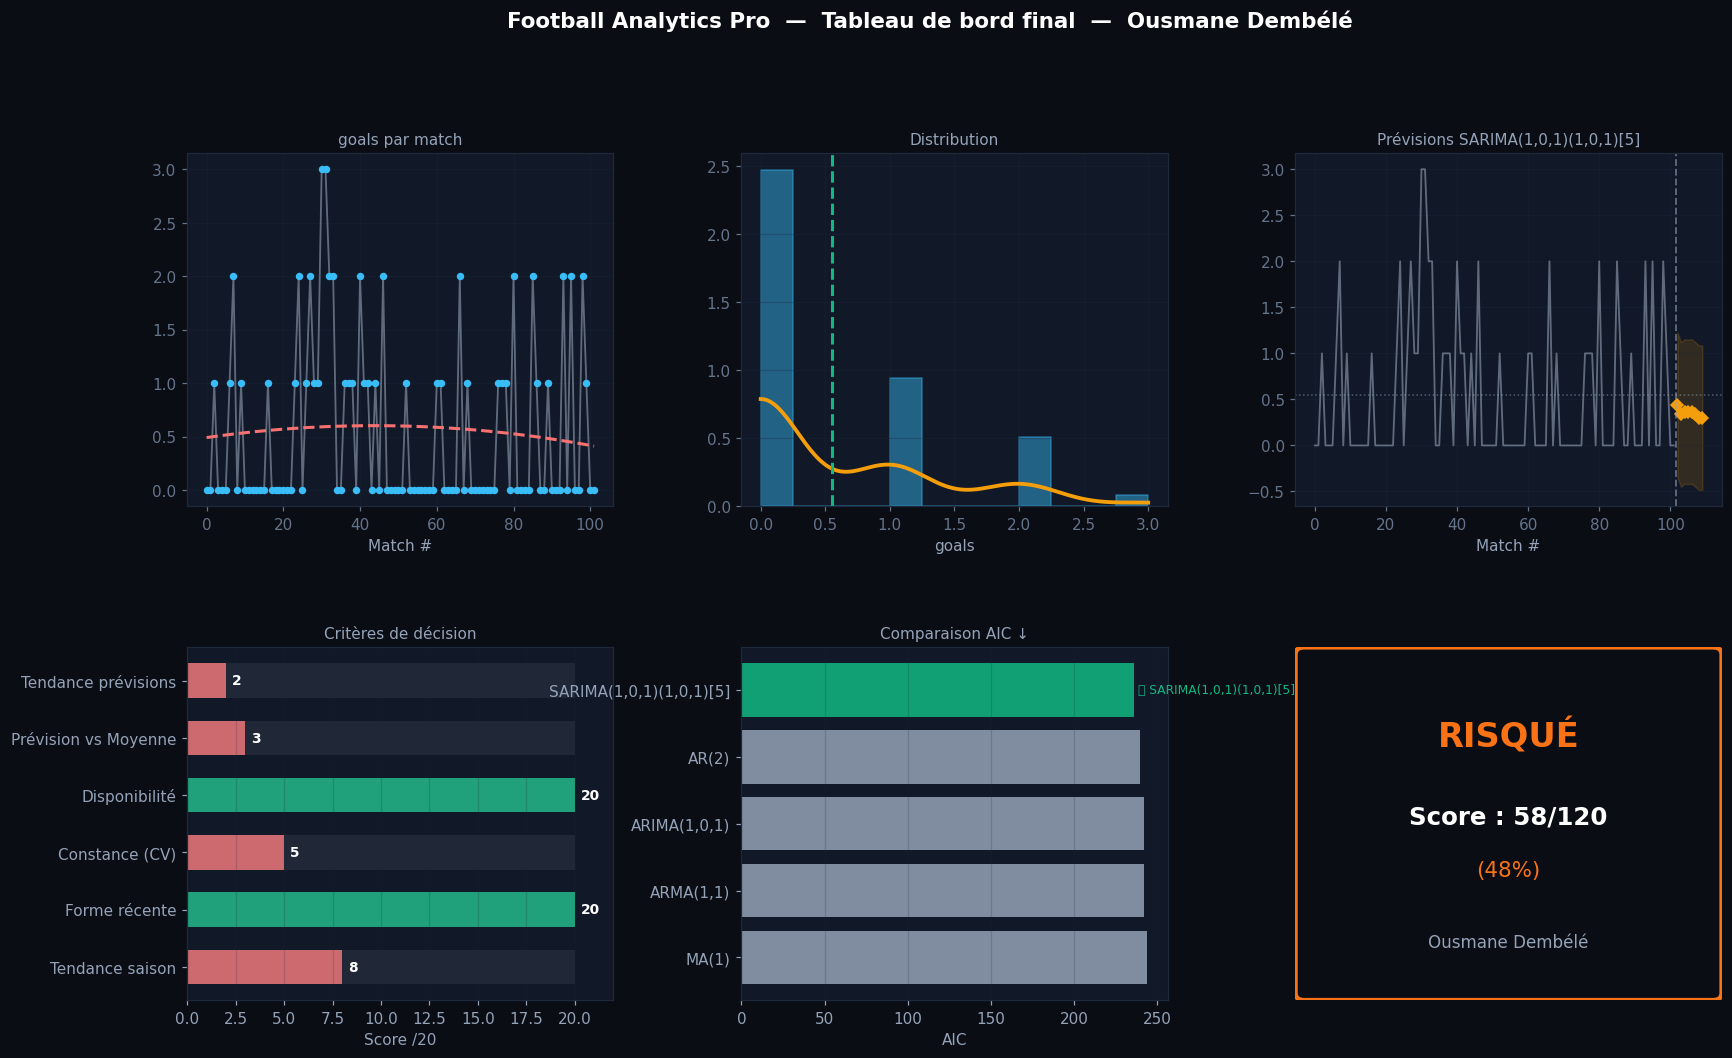


  Figures sauvegardées dans /tmp/
  ─ fig_exploration.png
  ─ fig_distribution.png
  ─ fig_correlations.png
  ─ fig_decomposition.png
  ─ fig_rolling_stats.png
  ─ fig_acf_pacf.png
  ─ fig_transforms.png
  ─ fig_model_comparison.png
  ─ fig_predictions_final.png
  ─ fig_decision_score.png
  ─ fig_dashboard_final.png
  ─ rapport_Ousmane_Demb_l__goals.txt

  ✅ Notebook complet exécuté avec succès !


In [32]:
# ── 12.2 Récapitulatif visuel final ──────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor("#0a0d14")
fig.suptitle(f"Football Analytics Pro  —  Tableau de bord final  —  {PLAYER_NAME}",
             fontsize=14, fontweight="bold", color="white", y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

# ── Top-gauche : série + tendance ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(MID)
ax1.plot(s.values, color=GRAY, lw=1.2, alpha=0.6)
ax1.scatter(range(len(s)), s.values, color=BLUE, s=15, zorder=3)
xf2 = np.arange(len(sc))
ax1.plot(xf2, np.poly1d(np.polyfit(xf2, sc.values, 2))(xf2),
         color=GREEN if slope_d>0 else RED, lw=2, ls="--")
ax1.set_title(f"{METRIC} par match", color=GRAY, fontsize=10)
ax1.set_xlabel("Match #", color=GRAY); ax1.grid(True, alpha=0.3)

# ── Top-centre : distribution ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(MID)
ax2.hist(s, bins=12, density=True, color=BLUE, alpha=0.45, edgecolor=BLUE, lw=0.5)
if s.std() > 0:
    xr = np.linspace(s.min(), s.max(), 200)
    ax2.plot(xr, gaussian_kde(s)(xr), color=ORANGE, lw=2.5)
ax2.axvline(s.mean(), color=GREEN, ls="--", lw=2)
ax2.set_title("Distribution", color=GRAY, fontsize=10)
ax2.set_xlabel(METRIC, color=GRAY); ax2.grid(True, alpha=0.3)

# ── Top-droit : prévisions ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(MID)
ax3.plot(range(n), s_model, color=GRAY, lw=1.2, alpha=0.6)
ax3.plot(range(n, n+N_FORECAST), best_fore, color=ORANGE,
         lw=2.5, ls="--", marker="D", ms=6)
ax3.fill_between(range(n, n+N_FORECAST),
                 best_fore-best_rmse, best_fore+best_rmse,
                 color=ORANGE, alpha=0.15)
ax3.axvline(n-0.5, color=GRAY, lw=1.2, ls="--", alpha=0.6)
ax3.axhline(current_mean, color=GRAY, ls=":", lw=1, alpha=0.5)
ax3.set_title(f"Prévisions {best_name}", color=GRAY, fontsize=10)
ax3.set_xlabel("Match #", color=GRAY); ax3.grid(True, alpha=0.3)

# ── Bas-gauche : critères de décision ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor(MID)
crit_names  = [c[0] for c in criteria]
crit_scores = [c[2] for c in criteria]
crit_cols   = [GREEN if s>=15 else ORANGE if s>=10 else RED for s in crit_scores]
bars4 = ax4.barh(crit_names, crit_scores, color=crit_cols, alpha=0.85, height=0.6)
ax4.barh(crit_names, [20]*len(criteria), color=GRAY, alpha=0.12, height=0.6)
ax4.set_xlim(0, 22); ax4.set_xlabel("Score /20", color=GRAY)
ax4.set_title("Critères de décision", color=GRAY, fontsize=10)
ax4.tick_params(colors=GRAY); ax4.grid(True, alpha=0.2, axis="x")
for bar, sc in zip(bars4, crit_scores):
    ax4.text(sc+0.3, bar.get_y()+bar.get_height()/2,
             f"{sc}", va="center", color="white", fontsize=9, fontweight="bold")

# ── Bas-centre : comparaison modèles ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor(MID)
bars5 = ax5.barh(comp_df["model"], comp_df["aic"],
                 color=[GREEN]+[GRAY]*(len(comp_df)-1), alpha=0.85)
ax5.set_title("Comparaison AIC ↓", color=GRAY, fontsize=10)
ax5.set_xlabel("AIC", color=GRAY)
ax5.tick_params(colors=GRAY); ax5.grid(True, alpha=0.2, axis="x")
ax5.invert_yaxis()
ax5.text(comp_df.iloc[0]["aic"]+abs(comp_df["aic"].mean())*0.01,
         0, f"✅ {comp_df.iloc[0]['model']}", va="center",
         color=GREEN, fontsize=8)

# ── Bas-droit : VERDICT ───────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor(bg_col); ax6.axis("off")
ax6.set_xlim(0, 1); ax6.set_ylim(0, 1)
ax6.text(0.5, 0.75, verdict, ha="center", va="center",
         color=vcol, fontsize=22, fontweight="bold")
ax6.text(0.5, 0.50, f"Score : {total}/{max_sc}", ha="center",
         color="white", fontsize=16, fontweight="bold")
ax6.text(0.5, 0.35, f"({pct:.0f}%)", ha="center", color=vcol, fontsize=14)
ax6.text(0.5, 0.15, PLAYER_NAME, ha="center", color=GRAY, fontsize=11)
ax6.add_patch(mpatches.FancyBboxPatch((0.02,0.02), 0.96, 0.96,
    boxstyle="round,pad=0.02", facecolor="none", edgecolor=vcol, lw=3))

plt.savefig("/tmp/fig_dashboard_final.png", dpi=130, bbox_inches="tight", facecolor="#0a0d14")
plt.show()

print(f"\n  Figures sauvegardées dans /tmp/")
print(f"  ─ fig_exploration.png")
print(f"  ─ fig_distribution.png")
print(f"  ─ fig_correlations.png")
print(f"  ─ fig_decomposition.png")
print(f"  ─ fig_rolling_stats.png")
print(f"  ─ fig_acf_pacf.png")
print(f"  ─ fig_transforms.png")
print(f"  ─ fig_model_comparison.png")
print(f"  ─ fig_predictions_final.png")
print(f"  ─ fig_decision_score.png")
print(f"  ─ fig_dashboard_final.png")
print(f"  ─ rapport_{re.sub(r'[^a-zA-Z0-9]','_',PLAYER_NAME)}_{METRIC}.txt")
print(f"\n  ✅ Notebook complet exécuté avec succès !")
